# **Project Name**    -



##### **Project Type**    - Data extraction, EDA , Regression ,Dashboard
##### **Contribution**    - Individual
##### **Team Member 1 -**  -  Neha Sanket Gaikwad

# **Project Summary -**

This project focuses on analyzing and visualizing digital payment transaction data from the PhonePe Pulse dataset to derive meaningful business insights and build an end-to-end data science solution. With the rapid growth of digital payment platforms in India, understanding transaction behavior, user engagement, insurance adoption, and regional performance has become increasingly important for improving customer experience and strategic decision-making. The primary objective of this project was to perform comprehensive data analysis, visualization, machine learning modeling, hypothesis testing, and dashboard development using real-world PhonePe data.

The project began with data extraction from the PhonePe Pulse GitHub repository. JSON files containing aggregated, map, and top-level transaction data were collected and transformed into structured tabular datasets using Python libraries such as Pandas and NumPy. Multiple datasets related to transactions, users, and insurance were processed and stored in a MySQL relational database. Nine different tables were created, including aggregated_transaction, aggregated_user, aggregated_insurance, map_transaction, map_user, map_insurance, top_transaction, top_user, and top_insurance. SQL queries were then used to perform exploratory analysis using concepts such as filtering, grouping, joins, aggregate functions, window functions, subqueries, common table expressions (CTEs), and ranking functions.

Further analysis was conducted in Python using Pandas, NumPy, Matplotlib, and Seaborn. Data cleaning techniques such as handling missing values, correcting data types, and feature engineering were applied to prepare the dataset for analysis and modeling. Exploratory Data Analysis (EDA) was performed to identify trends and patterns in transaction amount, transaction count, mobile brands, app opens, and user registrations across different states and years. Multiple visualizations such as bar charts, pie charts, line charts, heatmaps, and correlation plots were created to understand user behavior and business performance.

To extend the project into predictive analytics, machine learning models were developed to predict transaction amounts. Features such as state, year, quarter, transaction type, and transaction count were used for training. Data preprocessing techniques including encoding, scaling, and train-test splitting were applied before model building. Three regression algorithms — Linear Regression, Random Forest Regressor, and XGBoost Regressor — were implemented and evaluated using metrics such as MAE, RMSE, and R² Score. Hyperparameter tuning and cross-validation techniques were also applied to improve model performance. Among the models, XGBoost achieved the highest prediction accuracy and was selected as the final model. Feature importance analysis was performed to identify the most influential variables affecting transaction amount predictions.

Additionally, hypothesis testing was conducted to validate business assumptions statistically. Independent T-Test, Pearson Correlation Test, and ANOVA Test were used to examine relationships between transaction types, user engagement, and state-wise transaction behavior. The statistical analysis helped in drawing data-driven conclusions supported by p-values and significance testing.

Finally, an interactive Streamlit dashboard was developed to present the project results in a user-friendly manner. The dashboard included dynamic filters, KPI metrics, transaction trends, charts, and machine learning-based transaction prediction functionality. Users can explore state-wise and year-wise transaction insights and forecast future transaction amounts interactively. Overall, this project demonstrates strong capabilities in data engineering, SQL analysis, data visualization, statistical analysis, machine learning, and dashboard development using real-world financial transaction data.

# **GitHub Link -**

Provide your GitHub Link here.

# **Problem Statement**


The project aims to analyze PhonePe digital transaction, user, and insurance datasets to identify transaction trends, top-performing regions, user engagement patterns, and insurance growth. Interactive dashboards and predictive machine learning models are developed to generate business insights and forecast transaction amounts.

## ***1. Know Your Data***

In [7]:
#import library
import json

file_path = "pulse/data/aggregated/transaction/country/india/state/maharashtra/2021/1.json"

# printing raw data from json
with open(file_path,'r') as f:
    data = json.load(f)
print(data)    

{'success': True, 'code': 'SUCCESS', 'data': {'from': 1609439400000, 'to': 1616869800000, 'transactionData': [{'name': 'Merchant payments', 'paymentInstruments': [{'type': 'TOTAL', 'count': 253043309, 'amount': 129493046208.15726}]}, {'name': 'Peer-to-peer payments', 'paymentInstruments': [{'type': 'TOTAL', 'count': 187021609, 'amount': 599213284361.7993}]}, {'name': 'Recharge & bill payments', 'paymentInstruments': [{'type': 'TOTAL', 'count': 76389103, 'amount': 40057211827.15962}]}, {'name': 'Financial Services', 'paymentInstruments': [{'type': 'TOTAL', 'count': 439551, 'amount': 492900202.68315214}]}, {'name': 'Others', 'paymentInstruments': [{'type': 'TOTAL', 'count': 966668, 'amount': 630909553.4508264}]}]}, 'responseTimestamp': 1630501493982}


In [8]:
#read file
with open(file_path,'r') as f:
    data= json.load(f)

# printing each transaction block clearly
for item in data['data']['transactionData']:
    print(item)     

{'name': 'Merchant payments', 'paymentInstruments': [{'type': 'TOTAL', 'count': 253043309, 'amount': 129493046208.15726}]}
{'name': 'Peer-to-peer payments', 'paymentInstruments': [{'type': 'TOTAL', 'count': 187021609, 'amount': 599213284361.7993}]}
{'name': 'Recharge & bill payments', 'paymentInstruments': [{'type': 'TOTAL', 'count': 76389103, 'amount': 40057211827.15962}]}
{'name': 'Financial Services', 'paymentInstruments': [{'type': 'TOTAL', 'count': 439551, 'amount': 492900202.68315214}]}
{'name': 'Others', 'paymentInstruments': [{'type': 'TOTAL', 'count': 966668, 'amount': 630909553.4508264}]}


### What did you know about your dataset?

#### Data contain phonepe aggreagated , map & top  transaction , insurance amount  , registered users also app open data.

## ***2. Understanding Your Variables***

In [ ]:
#aggregated insurance 
#import libraries
import os
import json
import pandas as pd

rows = []

#india level

india_path = "pulse/data/aggregated/insurance/country/india"

for year in os.listdir(india_path):
    year_path = os.path.join(india_path, year)

    if os.path.isdir(year_path):

        for file in os.listdir(year_path):
            if file.endswith(".json"):

                quarter = int(file.replace(".json", ""))
                file_path = os.path.join(year_path, file)

                with open(file_path, "r") as f:
                    data = json.load(f)

                try:
                    for item in data["data"]["transactionData"]:
                        name = item["name"]

                        for inst in item["paymentInstruments"]:
                            rows.append([
                                "india",        # level
                                None,           # state
                                int(year),
                                quarter,
                                name,
                                inst["count"],
                                inst["amount"]
                            ])
                except:
                    continue


#state level

state_base_path = "pulse/data/aggregated/insurance/country/india/state"

for state in os.listdir(state_base_path):
    state_path = os.path.join(state_base_path, state)

    for year in os.listdir(state_path):
        year_path = os.path.join(state_path, year)

        for file in os.listdir(year_path):
            if file.endswith(".json"):

                quarter = int(file.replace(".json", ""))
                file_path = os.path.join(year_path, file)

                with open(file_path, "r") as f:
                    data = json.load(f)

                try:
                    for item in data["data"]["transactionData"]:
                        name = item["name"]

                        for inst in item["paymentInstruments"]:
                            rows.append([
                                "state",       # level
                                state,
                                int(year),
                                quarter,
                                name,
                                inst["count"],
                                inst["amount"]
                            ])
                except:
                    continue


#create dataframe

df = pd.DataFrame(rows, columns=[
    "level", "state", "year", "quarter",
    "insurance_type", "count", "amount"
])

#save csv 

df.to_csv("aggregated_insurance_combined.csv", index=False)

print("Done. Total Rows:", len(df))

In [ ]:
#aggregated transaction
#import libraries
import os
import json
import pandas as pd

rows = []

#india level 

india_path = "pulse/data/aggregated/transaction/country/india"

for year in os.listdir(india_path):
    year_path = os.path.join(india_path, year)

    if os.path.isdir(year_path):

        for file in os.listdir(year_path):
            if file.endswith(".json"):

                quarter = int(file.replace(".json", ""))
                file_path = os.path.join(year_path, file)

                with open(file_path, "r") as f:
                    data = json.load(f)

                try:
                    for item in data["data"]["transactionData"]:
                        name = item["name"]

                        for inst in item["paymentInstruments"]:
                            rows.append([
                                "india",        # level
                                None,           # state
                                int(year),
                                quarter,
                                name,
                                inst["count"],
                                inst["amount"]
                            ])
                except:
                    continue


#state level 

state_base_path = "pulse/data/aggregated/transaction/country/india/state"

for state in os.listdir(state_base_path):
    state_path = os.path.join(state_base_path, state)

    for year in os.listdir(state_path):
        year_path = os.path.join(state_path, year)

        for file in os.listdir(year_path):
            if file.endswith(".json"):

                quarter = int(file.replace(".json", ""))
                file_path = os.path.join(year_path, file)

                with open(file_path, "r") as f:
                    data = json.load(f)

                try:
                    for item in data["data"]["transactionData"]:
                        name = item["name"]

                        for inst in item["paymentInstruments"]:
                            rows.append([
                                "state",       # level
                                state,
                                int(year),
                                quarter,
                                name,
                                inst["count"],
                                inst["amount"]
                            ])
                except:
                    continue


#create dataframe

df = pd.DataFrame(rows, columns=[
    "level", "state", "year", "quarter",
    "transaction_type", "count", "amount"
])

#save csv 

df.to_csv("aggregated_transaction_combined.csv", index=False)

print("Done. Total Rows:", len(df))

Done. Total Rows: 5174


In [ ]:
#aggregated user
#import libraries
import os
import json
import pandas as pd

rows = []

#india level

india_path = "pulse/data/aggregated/user/country/india"

for year in os.listdir(india_path):
    year_path = os.path.join(india_path, year)

    if os.path.isdir(year_path):

        for file in os.listdir(year_path):
            if file.endswith(".json"):

                quarter = int(file.replace(".json", ""))
                file_path = os.path.join(year_path, file)

                with open(file_path, "r") as f:
                    data = json.load(f)

                try:
                    users = data["data"]

                    total_users = users["aggregated"]["registeredUsers"]
                    app_opens = users["aggregated"]["appOpens"]

                    for device in users["usersByDevice"]:
                        rows.append([
                            "india",
                            None,
                            int(year),
                            quarter,
                            device["brand"],
                            device["count"],
                            device["percentage"],
                            total_users,
                            app_opens
                        ])
                except:
                    continue


#state level

state_base_path = "pulse/data/aggregated/user/country/india/state"

for state in os.listdir(state_base_path):
    state_path = os.path.join(state_base_path, state)

    for year in os.listdir(state_path):
        year_path = os.path.join(state_path, year)

        for file in os.listdir(year_path):
            if file.endswith(".json"):

                quarter = int(file.replace(".json", ""))
                file_path = os.path.join(year_path, file)

                with open(file_path, "r") as f:
                    data = json.load(f)

                try:
                    users = data["data"]

                    total_users = users["aggregated"]["registeredUsers"]
                    app_opens = users["aggregated"]["appOpens"]

                    for device in users["usersByDevice"]:
                        rows.append([
                            "state",
                            state,
                            int(year),
                            quarter,
                            device["brand"],
                            device["count"],
                            device["percentage"],
                            total_users,
                            app_opens
                        ])
                except:
                    continue


#create dataframe 

df = pd.DataFrame(rows, columns=[
    "level", "state", "year", "quarter",
    "brand", "count", "percentage",
    "registered_users", "app_opens"
])

#csv save

df.to_csv("aggregated_user_combined.csv", index=False)

print("Done. Rows:", len(df))

Done. Rows: 6919


In [ ]:
#map user
#import libraries
import os
import json
import pandas as pd

rows = []

#india level

india_path = "pulse/data/map/user/hover/country/india"

for year in os.listdir(india_path):

    year_path = os.path.join(india_path, year)

    if os.path.isdir(year_path):

        for file in os.listdir(year_path):

            if file.endswith(".json"):

                quarter = int(file.replace(".json", ""))

                file_path = os.path.join(year_path, file)

                with open(file_path, "r") as f:
                    data = json.load(f)

                try:

                    hover_data = data["data"]["hoverData"]

                    for region, values in hover_data.items():

                        rows.append([
                            "india",
                            None,
                            int(year),
                            quarter,
                            region,
                            values["registeredUsers"],
                            values["appOpens"]
                        ])

                except:
                    continue


#state level

state_base_path = "pulse/data/map/user/hover/country/india/state"

for state in os.listdir(state_base_path):

    state_path = os.path.join(state_base_path, state)

    for year in os.listdir(state_path):

        year_path = os.path.join(state_path, year)

        for file in os.listdir(year_path):

            if file.endswith(".json"):

                quarter = int(file.replace(".json", ""))

                file_path = os.path.join(year_path, file)

                with open(file_path, "r") as f:
                    data = json.load(f)

                try:

                    hover_data = data["data"]["hoverData"]

                    for district, values in hover_data.items():

                        rows.append([
                            "state",
                            state,
                            int(year),
                            quarter,
                            district,
                            values["registeredUsers"],
                            values["appOpens"]
                        ])

                except:
                    continue


#create dataframe

df = pd.DataFrame(rows, columns=[
    "level",
    "state",
    "year",
    "quarter",
    "region_name",
    "registered_users",
    "app_opens"
])


#save csv

df.to_csv("map_user_hover_combined.csv", index=False)

print("Done. Total rows:", len(df))

Done. Total rows: 21616


In [ ]:
#map insurance
#import libraries
import os
import json
import pandas as pd

rows = []

#india level

india_path = "pulse/data/map/insurance/country/india"

for year in os.listdir(india_path):

    year_path = os.path.join(india_path, year)

    if os.path.isdir(year_path):

        for file in os.listdir(year_path):

            if file.endswith(".json"):

                quarter = int(file.replace(".json", ""))

                file_path = os.path.join(year_path, file)

                with open(file_path, "r") as f:
                    data = json.load(f)

                try:
                    map_data = data["data"]["data"]["data"]

                    for item in map_data:

                        rows.append([
                            "india",
                            None,
                            int(year),
                            quarter,
                            item[0],   # lat
                            item[1],   # lng
                            item[2],   # metric
                            item[3]    # label/state
                        ])

                except:
                    continue


#state level

state_base_path = "pulse/data/map/insurance/country/india/state"

for state in os.listdir(state_base_path):

    state_path = os.path.join(state_base_path, state)

    for year in os.listdir(state_path):

        year_path = os.path.join(state_path, year)

        for file in os.listdir(year_path):

            if file.endswith(".json"):

                quarter = int(file.replace(".json", ""))

                file_path = os.path.join(year_path, file)

                with open(file_path, "r") as f:
                    data = json.load(f)

                try:
                    map_data = data["data"]["data"]["data"]
                    for item in map_data:

                        rows.append([
                            "state",
                            state,
                            int(year),
                            quarter,
                            item[0],   # lat
                            item[1],   # lng
                            item[2],   # metric
                            item[3]    # label
                        ])

                except:
                    continue


#create dataframe

df = pd.DataFrame(rows, columns=[
    "level",
    "state",
    "year",
    "quarter",
    "latitude",
    "longitude",
    "metric",
    "label"
])

#save csv

df.to_csv("map_insurance_combined.csv", index=False)

print("Done. Total rows:", len(df))

Done. Total rows: 1430349


In [ ]:
#map transaction
#import libraries
import os
import json
import pandas as pd

rows = []

#india level

india_path = "pulse/data/map/transaction/hover/country/india"

for year in os.listdir(india_path):

    year_path = os.path.join(india_path, year)

    if os.path.isdir(year_path):

        for file in os.listdir(year_path):

            if file.endswith(".json"):

                quarter = int(file.replace(".json", ""))

                file_path = os.path.join(year_path, file)

                with open(file_path, "r") as f:
                    data = json.load(f)

                try:

                    hover_data = data["data"]["hoverDataList"]

                    for item in hover_data:

                        state_name = item["name"]

                        for metric in item["metric"]:

                            rows.append([
                                "india",
                                None,
                                int(year),
                                quarter,
                                state_name,
                                metric["type"],
                                metric["count"],
                                metric["amount"]
                            ])

                except:
                    continue


#state level

state_base_path = "pulse/data/map/transaction/hover/country/india/state"

for state in os.listdir(state_base_path):

    state_path = os.path.join(state_base_path, state)

    for year in os.listdir(state_path):

        year_path = os.path.join(state_path, year)

        for file in os.listdir(year_path):

            if file.endswith(".json"):

                quarter = int(file.replace(".json", ""))

                file_path = os.path.join(year_path, file)

                with open(file_path, "r") as f:
                    data = json.load(f)

                try:

                    hover_data = data["data"]["hoverDataList"]

                    for item in hover_data:

                        district_name = item["name"]

                        for metric in item["metric"]:

                            rows.append([
                                "state",
                                state,
                                int(year),
                                quarter,
                                district_name,
                                metric["type"],
                                metric["count"],
                                metric["amount"]
                            ])

                except:
                    continue


#create dataframe

df = pd.DataFrame(rows, columns=[
    "level",
    "state",
    "year",
    "quarter",
    "region_name",
    "transaction_type",
    "count",
    "amount"
])


#csv save

df.to_csv("map_transaction_hover_combined.csv", index=False)

print("Done. Total rows:", len(df))

Done. Total rows: 21612


In [ ]:
#top transaction
#import librariees
import os
import json
import pandas as pd

rows = []

#india level

india_path = "pulse/data/top/transaction/country/india"

for year in os.listdir(india_path):

    year_path = os.path.join(india_path, year)

    if os.path.isdir(year_path):

        for file in os.listdir(year_path):

            if file.endswith(".json"):

                quarter = int(file.replace(".json", ""))

                file_path = os.path.join(year_path, file)

                with open(file_path, "r") as f:
                    data = json.load(f)

                try:

                    top_data = data["data"]

                    # -------- STATES --------
                    for item in top_data["states"]:

                        rows.append([
                            "india",
                            None,
                            int(year),
                            quarter,
                            "state",
                            item["entityName"],
                            item["metric"]["type"],
                            item["metric"]["count"],
                            item["metric"]["amount"]
                        ])

                    # -------- DISTRICTS --------
                    for item in top_data["districts"]:

                        rows.append([
                            "india",
                            None,
                            int(year),
                            quarter,
                            "district",
                            item["entityName"],
                            item["metric"]["type"],
                            item["metric"]["count"],
                            item["metric"]["amount"]
                        ])

                    # -------- PINCODES --------
                    for item in top_data["pincodes"]:

                        rows.append([
                            "india",
                            None,
                            int(year),
                            quarter,
                            "pincode",
                            item["entityName"],
                            item["metric"]["type"],
                            item["metric"]["count"],
                            item["metric"]["amount"]
                        ])

                except:
                    continue


#state level

state_base_path = "pulse/data/top/transaction/country/india/state"

for state in os.listdir(state_base_path):

    state_path = os.path.join(state_base_path, state)

    for year in os.listdir(state_path):

        year_path = os.path.join(state_path, year)

        for file in os.listdir(year_path):

            if file.endswith(".json"):

                quarter = int(file.replace(".json", ""))

                file_path = os.path.join(year_path, file)

                with open(file_path, "r") as f:
                    data = json.load(f)

                try:

                    top_data = data["data"]

                    # -------- DISTRICTS --------
                    for item in top_data["districts"]:

                        rows.append([
                            "state",
                            state,
                            int(year),
                            quarter,
                            "district",
                            item["entityName"],
                            item["metric"]["type"],
                            item["metric"]["count"],
                            item["metric"]["amount"]
                        ])

                    # -------- PINCODES --------
                    for item in top_data["pincodes"]:

                        rows.append([
                            "state",
                            state,
                            int(year),
                            quarter,
                            "pincode",
                            item["entityName"],
                            item["metric"]["type"],
                            item["metric"]["count"],
                            item["metric"]["amount"]
                        ])

                except:
                    continue


#create dataframe

df = pd.DataFrame(rows, columns=[
    "level",
    "state",
    "year",
    "quarter",
    "entity_type",
    "entity_name",
    "metric_type",
    "count",
    "amount"
])


#save csv

df.to_csv("top_transaction_combined.csv", index=False)

print("Done. Total rows:", len(df))

Done. Total rows: 19135


In [ ]:
#top insurance
#import libraries
import os
import json
import pandas as pd

rows = []

#india level

india_path = "pulse/data/top/insurance/country/india"

for year in os.listdir(india_path):

    year_path = os.path.join(india_path, year)

    if os.path.isdir(year_path):

        for file in os.listdir(year_path):

            if file.endswith(".json"):

                quarter = int(file.replace(".json", ""))

                file_path = os.path.join(year_path, file)

                with open(file_path, "r") as f:
                    data = json.load(f)

                try:

                    top_data = data["data"]

                    # ---------------- STATES ----------------
                    for item in top_data["states"]:

                        rows.append([
                            "india",
                            None,
                            int(year),
                            quarter,
                            "state",
                            item["entityName"],
                            item["metric"]["type"],
                            item["metric"]["count"],
                            item["metric"]["amount"]
                        ])

                    # ---------------- DISTRICTS ----------------
                    for item in top_data["districts"]:

                        rows.append([
                            "india",
                            None,
                            int(year),
                            quarter,
                            "district",
                            item["entityName"],
                            item["metric"]["type"],
                            item["metric"]["count"],
                            item["metric"]["amount"]
                        ])

                    # ---------------- PINCODES ----------------
                    for item in top_data["pincodes"]:

                        rows.append([
                            "india",
                            None,
                            int(year),
                            quarter,
                            "pincode",
                            item["entityName"],
                            item["metric"]["type"],
                            item["metric"]["count"],
                            item["metric"]["amount"]
                        ])

                except:
                    continue


#state level

state_base_path = "pulse/data/top/insurance/country/india/state"

for state in os.listdir(state_base_path):

    state_path = os.path.join(state_base_path, state)

    for year in os.listdir(state_path):

        year_path = os.path.join(state_path, year)

        for file in os.listdir(year_path):

            if file.endswith(".json"):

                quarter = int(file.replace(".json", ""))

                file_path = os.path.join(year_path, file)

                with open(file_path, "r") as f:
                    data = json.load(f)

                try:

                    top_data = data["data"]

                    # ---------------- DISTRICTS ----------------
                    for item in top_data["districts"]:

                        rows.append([
                            "state",
                            state,
                            int(year),
                            quarter,
                            "district",
                            item["entityName"],
                            item["metric"]["type"],
                            item["metric"]["count"],
                            item["metric"]["amount"]
                        ])

                    # ---------------- PINCODES ----------------
                    for item in top_data["pincodes"]:

                        rows.append([
                            "state",
                            state,
                            int(year),
                            quarter,
                            "pincode",
                            item["entityName"],
                            item["metric"]["type"],
                            item["metric"]["count"],
                            item["metric"]["amount"]
                        ])

                except:
                    continue


#create dataframe

df = pd.DataFrame(rows, columns=[
    "level",
    "state",
    "year",
    "quarter",
    "entity_type",
    "entity_name",
    "metric_type",
    "count",
    "amount"
])


#save csv

df.to_csv("top_insurance_combined.csv", index=False)

print("Done. Total rows:", len(df)) 

Done. Total rows: 12846


In [ ]:
#top user
#import libraries
import os
import json
import pandas as pd

rows = []

#india level

india_path = "pulse/data/top/user/country/india"

for year in os.listdir(india_path):

    year_path = os.path.join(india_path, year)

    if os.path.isdir(year_path):

        for file in os.listdir(year_path):

            if file.endswith(".json"):

                quarter = int(file.replace(".json", ""))

                file_path = os.path.join(year_path, file)

                with open(file_path, "r") as f:
                    data = json.load(f)

                try:

                    top_data = data["data"]

                    # -------- STATES --------
                    for item in top_data["states"]:

                        rows.append([
                            "india",
                            None,
                            int(year),
                            quarter,
                            "state",
                            item["name"],
                            item["registeredUsers"]
                        ])

                    # -------- DISTRICTS --------
                    for item in top_data["districts"]:

                        rows.append([
                            "india",
                            None,
                            int(year),
                            quarter,
                            "district",
                            item["name"],
                            item["registeredUsers"]
                        ])

                    # -------- PINCODES --------
                    for item in top_data["pincodes"]:

                        rows.append([
                            "india",
                            None,
                            int(year),
                            quarter,
                            "pincode",
                            item["name"],
                            item["registeredUsers"]
                        ])

                except:
                    continue


#state level

state_base_path = "pulse/data/top/user/country/india/state"

for state in os.listdir(state_base_path):

    state_path = os.path.join(state_base_path, state)

    for year in os.listdir(state_path):

        year_path = os.path.join(state_path, year)

        for file in os.listdir(year_path):

            if file.endswith(".json"):

                quarter = int(file.replace(".json", ""))

                file_path = os.path.join(year_path, file)

                with open(file_path, "r") as f:
                    data = json.load(f)

                try:

                    top_data = data["data"]

                    # -------- DISTRICTS --------
                    for item in top_data["districts"]:

                        rows.append([
                            "state",
                            state,
                            int(year),
                            quarter,
                            "district",
                            item["name"],
                            item["registeredUsers"]
                        ])

                    # -------- PINCODES --------
                    for item in top_data["pincodes"]:

                        rows.append([
                            "state",
                            state,
                            int(year),
                            quarter,
                            "pincode",
                            item["name"],
                            item["registeredUsers"]
                        ])

                except:
                    continue


#create dataframe

df = pd.DataFrame(rows, columns=[
    "level",
    "state",
    "year",
    "quarter",
    "entity_type",
    "entity_name",
    "registered_users"
])

#csv save

df.to_csv("top_user_combined.csv", index=False)

print("Done. Total rows:", len(df))

Done. Total rows: 19136


## 3. ***Data Wrangling***

#### Load data into tables

In [ ]:
#import libraries
import mysql.connector 
import pandas as pd 
import load_ssql

load_ssql.cursor.execute("Use phonepe;")

#table creation queries
table_queries = {

    "aggregated_transaction": """
        CREATE TABLE IF NOT EXISTS aggregated_transaction (
            level VARCHAR(20),
            state VARCHAR(100),
            year INT,
            quarter INT,
            transaction_type VARCHAR(100),
            count BIGINT,
            amount DOUBLE
        )
    """,

    "aggregated_user": """
        CREATE TABLE IF NOT EXISTS aggregated_user (
            level VARCHAR(20),
            state VARCHAR(100),
            year INT,
            quarter INT,
            brand VARCHAR(100),
            count BIGINT,
            percentage DOUBLE,
            registered_users BIGINT,
            app_opens BIGINT
        )
    """,

    "aggregated_insurance": """
        CREATE TABLE IF NOT EXISTS aggregated_insurance (
            level VARCHAR(20),
            state VARCHAR(100),
            year INT,
            quarter INT,
            insurance_type VARCHAR(100),
            count BIGINT,
            amount DOUBLE
        )
    """,

    "map_transaction": """
        CREATE TABLE IF NOT EXISTS map_transaction (
            level VARCHAR(20),
    state VARCHAR(100),
    year INT,
    quarter INT,
    region_name VARCHAR(200),
    transaction_type VARCHAR(50),
    count BIGINT,
    amount DOUBLE
        )
    """,

    "map_user": """
        CREATE TABLE IF NOT EXISTS map_user (
            level VARCHAR(20),
            state VARCHAR(100),
            year INT,
            quarter INT,
            region_name VARCHAR(200),
            registered_users BIGINT,
            app_opens BIGINT
        )
    """,

    "map_insurance": """
        CREATE TABLE IF NOT EXISTS map_insurance (
            level VARCHAR(20),
            state VARCHAR(100),
            year INT,
            quarter INT,
            latitude DECIMAL,
            longitude DECIMAL,
            metric BIGINT,
            label VARCHAR(200)
        )
    """,

    "top_transaction": """
        CREATE TABLE IF NOT EXISTS top_transaction (
            level VARCHAR(20),
            state VARCHAR(100),
            year INT,
            quarter INT,
            entity_type VARCHAR(50),
            entity_name VARCHAR(200),
            metric_type VARCHAR(50),
            count BIGINT,
            amount DOUBLE
        )
    """,

    "top_user": """
        CREATE TABLE IF NOT EXISTS top_user (
            level VARCHAR(20),
            state VARCHAR(100),
            year INT,
            quarter INT,
            entity_type VARCHAR(50),
            entity_name VARCHAR(200),
            registered_users BIGINT
        )
    """,

    "top_insurance": """
        CREATE TABLE IF NOT EXISTS top_insurance (
            level VARCHAR(20),
            state VARCHAR(100),
            year INT,
            quarter INT,
            entity_type VARCHAR(50),
            entity_name VARCHAR(200),
            metric_type VARCHAR(50),
            count BIGINT,
            amount DOUBLE
        )
    """
}


#create tables

for table_name, query in table_queries.items():

    load_ssql.cursor.execute(query)

    print(f"{table_name} table created")


#csv mapping

csv_files = {

    "aggregated_transaction":
        "aggregated_transaction_combined.csv",

    "aggregated_user":
        "aggregated_user_combined.csv",

    "aggregated_insurance":
        "aggregated_insurance_combined.csv",

    "map_transaction":
        "map_transaction_hover_combined.csv",

    "map_user":
        "map_user_hover_combined.csv",

    "map_insurance":
        "map_insurance_combined.csv",

    "top_transaction":
        "top_transaction_combined.csv",

    "top_user":
        "top_user_combined.csv",

    "top_insurance":
        "top_insurance_combined.csv"
}


#load all csv

for table_name, file_name in csv_files.items():

    print(f"\nLoading {file_name}...")

    df = pd.read_csv(file_name)

    #converting NAN -> None
    df = df.where(pd.notnull(df), None)

    columns = ", ".join(df.columns)

    # Create placeholders
    placeholders = ", ".join(["%s"] * len(df.columns))

    insert_query = f"""
        INSERT INTO {table_name}({columns})
        VALUES ({placeholders})
    """

    for row in df.itertuples(index=False):

        load_ssql.cursor.execute(insert_query, tuple(row))

    load_ssql.conn.commit()

    print(f"{table_name} loaded successfully")


#close connection
load_ssql.cursor.close()
load_ssql.conn.close()

print("\nAll tables loaded successfully")

aggregated_transaction table created
aggregated_user table created
aggregated_insurance table created
map_transaction table created
map_user table created
map_insurance table created
top_transaction table created
top_user table created
top_insurance table created

Loading aggregated_transaction_combined.csv...
aggregated_transaction loaded successfully

Loading aggregated_user_combined.csv...
aggregated_user loaded successfully

Loading aggregated_insurance_combined.csv...
aggregated_insurance loaded successfully

Loading map_transaction_hover_combined.csv...
map_transaction loaded successfully

Loading map_user_hover_combined.csv...
map_user loaded successfully

Loading map_insurance_combined.csv...


C:\Users\NEHA\AppData\Local\Temp\ipykernel_27344\1582949996.py:177: DtypeWarning: Columns (1) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(file_name)


map_insurance loaded successfully

Loading top_transaction_combined.csv...
top_transaction loaded successfully

Loading top_user_combined.csv...
top_user loaded successfully

Loading top_insurance_combined.csv...
top_insurance loaded successfully

All tables loaded successfully


### Data Analysis with SQL

In [27]:
import importlib
import load_ssql

importlib.reload(load_ssql)

Connected Successfully!


<module 'load_ssql' from 'c:\\Users\\NEHA\\DataScienceBatch25Sept\\Projects\\Internship\\Labmentix Internship\\load_ssql.py'>

In [28]:
load_ssql.cursor.execute("USE PHONEPE")

In [29]:
load_ssql.cursor.execute("Show tables")

for table in load_ssql.cursor.fetchall():
    print(table)

('aggregated_insurance',)
('aggregated_transaction',)
('aggregated_user',)
('map_insurance',)
('map_transaction',)
('map_user',)
('top_insurance',)
('top_transaction',)
('top_user',)


In [ ]:
load_ssql.cursor.execute("SELECT * FROM aggregated_insurance LIMIT 10")

print(load_ssql.cursor.column_names)

for row in load_ssql.cursor.fetchall():
    print(row)

('level', 'state', 'year', 'quarter', 'insurance_type', 'count', 'amount')
('india', None, 2020, 2, 'Insurance', 185348, 33732166.0)
('india', None, 2020, 3, 'Insurance', 354284, 89495076.0)
('india', None, 2020, 4, 'Insurance', 248626, 170979933.0)
('india', None, 2021, 1, 'Insurance', 318119, 206307024.0)
('india', None, 2021, 2, 'Insurance', 363989, 295066678.0)
('india', None, 2021, 3, 'Insurance', 374867, 342403352.0)
('india', None, 2021, 4, 'Insurance', 526327, 655431877.0)
('india', None, 2022, 1, 'Insurance', 617606, 887447241.0)
('india', None, 2022, 2, 'Insurance', 630758, 857034846.0)
('india', None, 2022, 3, 'Insurance', 806491, 1054717869.0)


In [ ]:
import pandas as pd 

table_names = ["AGGREGATED_INSURANCE",
         "aggregated_transaction","aggregated_user",
"map_insurance","map_transaction","map_user","top_insurance","top_transaction","top_user"]

for table in table_names:

    print(f'{table.title()}')

    query = f'SELECT * FROM {table} LIMIT 2'

    df = pd.read_sql(query,load_ssql.conn)
    print(df)



Aggregated_Insurance
   level state  year  quarter insurance_type   count      amount
0  india  None  2020        2      Insurance  185348  33732166.0
1  india  None  2020        3      Insurance  354284  89495076.0
Aggregated_Transaction
   level state  year  quarter          transaction_type     count  \
0  india  None  2018        1  Recharge & bill payments  72550406   
1  india  None  2018        1     Peer-to-peer payments  46982705   

         amount  
0  1.447271e+10  
1  1.472459e+11  
Aggregated_User
   level state  year  quarter    brand     count  percentage  \
0  india  None  2018        1   Xiaomi  11926334    0.254413   
1  india  None  2018        1  Samsung   9609401    0.204988   

   registered_users  app_opens  
0          46877867          0  
1          46877867          0  
Map_Insurance
   level state  year  quarter  latitude  longitude  metric      label
0  india  None  2020        2      13.0       78.0    4720  karnataka
1  india  None  2020        2      17

C:\Users\NEHA\AppData\Local\Temp\ipykernel_8308\2296995958.py:13: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query,load_ssql.conn)
C:\Users\NEHA\AppData\Local\Temp\ipykernel_8308\2296995958.py:13: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query,load_ssql.conn)
C:\Users\NEHA\AppData\Local\Temp\ipykernel_8308\2296995958.py:13: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query,load_ssql.conn)
C:\Users\NEHA\AppData\Local\Temp\ipykernel_8308\2296995958.py:13: UserWarnin

#### Aggregated Transaction

In [37]:
# 1.Total transaction amount by state

# Clear previous unread results
try:
    load_ssql.cursor.fetchall()
except:
    pass

load_ssql.cursor.execute("select state,SUM(amount) as total_amount from aggregated_transaction where state is not null group by state order by total_amount desc")

for row in load_ssql.cursor.fetchall():
    print(row)

('telangana', 41655955630076.31)
('karnataka', 40678721773666.375)
('maharashtra', 40374195687971.67)
('andhra-pradesh', 34669080454846.836)
('uttar-pradesh', 26885212184899.867)
('rajasthan', 26343235566259.24)
('madhya-pradesh', 19125279433026.816)
('bihar', 17901349344779.723)
('west-bengal', 15584164309413.684)
('odisha', 12263982051532.62)
('tamil-nadu', 11936219022648.531)
('delhi', 11637520248963.953)
('gujarat', 10192905823125.367)
('haryana', 9645036562815.904)
('jharkhand', 5906646115660.92)
('chhattisgarh', 4890472317487.816)
('assam', 3460792155997.8906)
('kerala', 3076269164129.138)
('punjab', 2983077809927.293)
('uttarakhand', 1916488572014.317)
('jammu-&-kashmir', 1184683177572.731)
('himachal-pradesh', 687537358746.4001)
('goa', 511021161407.30316)
('chandigarh', 292906588372.68616)
('arunachal-pradesh', 274434950651.68097)
('puducherry', 237317074404.26514)
('dadra-&-nagar-haveli-&-daman-&-diu', 201719857192.11563)
('tripura', 200583408419.46307)
('manipur', 1862656350

##### Conclusion: Telanagana has the highest transaction amount.

In [ ]:
# 2.Total transaction 
try:
   load_ssql.cursor.fetchall()
except:
   pass 

load_ssql.cursor.execute("select transaction_type, sum(count) as total_transaction from aggregated_transaction where state is not group by transaction_type order by total_transaction desc")

for row in load_ssql.cursor.fetchall():
   print(row)

('Merchant payments', Decimal('3125733996324'))
('Peer-to-peer payments', Decimal('2040782130396'))
('Recharge & bill payments', Decimal('470323087368'))
('Others', Decimal('6289213320'))
('Financial Services', Decimal('3701029932'))


##### Conclusion: Merchant payments is top transaction type.

In [ ]:
# 3.Quarterly growth
try:  
  load_ssql.cursor.fetchall()
except:
  pass 

load_ssql.cursor.execute("select year,quarter,sum(amount) as total_amount from aggregated_transaction group by year , quarter order by year,quarter desc")

for row in load_ssql.cursor.fetchall():
  print(row)


(2018, 4, 16121749181200.986)
(2018, 3, 11402488731135.904)
(2018, 2, 7305004967335.901)
(2018, 1, 4124013329282.5874)
(2019, 4, 54237527370008.96)
(2019, 3, 40141489138440.97)
(2019, 2, 32501229134139.234)
(2019, 1, 23760618736565.508)
(2020, 4, 129500779616896.47)
(2020, 3, 93649456850625.08)
(2020, 2, 63507590238002.87)
(2020, 1, 64730785110813.55)
(2021, 4, 278911832290010.6)
(2021, 3, 221201328456853.94)
(2021, 2, 179435667249900.8)
(2021, 1, 150822273136150.53)
(2022, 4, 453958353066782.4)
(2022, 3, 398584012645454.56)
(2022, 2, 372101459771613.8)
(2022, 1, 317751950864426.2)
(2023, 4, 649135346798832.0)
(2023, 3, 576292930173840.0)
(2023, 2, 550045642690632.0)
(2023, 1, 492336328107036.0)
(2024, 4, 863971221230328.0)
(2024, 3, 776327223127440.0)
(2024, 2, 763690414569336.0)
(2024, 1, 707004191871060.0)


##### Conclusion: (2018, 4, 16121749181200.986) 2018 year's 4th quarter has highest total amount.

In [ ]:
# 4.States with transaction amount > 1 billion

try:
    load_ssql.cursor.fetchall()
except:
    pass

load_ssql.cursor.execute("select state,sum(amount) as total_amount from aggregated_transaction group by state having total_amount > 1000000000")

for row in load_ssql.cursor.fetchall():
    print(row)

(None, 4146285370429516.0)
('andaman-&-nicobar-islands', 848009437759.1765)
('andhra-pradesh', 416028965458162.44)
('arunachal-pradesh', 3293219407820.1753)
('assam', 41529505871974.75)
('bihar', 214816192137356.56)
('chandigarh', 3514879060472.2383)
('chhattisgarh', 58685667809853.914)
('dadra-&-nagar-haveli-&-daman-&-diu', 2420638286305.394)
('delhi', 139650242987567.31)
('goa', 6132253936887.642)
('gujarat', 122314869877504.45)
('haryana', 115740438753790.75)
('himachal-pradesh', 8250448304956.821)
('jammu-&-kashmir', 14216198130872.764)
('jharkhand', 70879753387931.14)
('karnataka', 488144661283996.56)
('kerala', 36915229969549.625)
('ladakh', 1067935465201.2275)
('lakshadweep', 19311849417.32574)
('madhya-pradesh', 229503353196320.9)
('maharashtra', 484490348255662.0)
('manipur', 2235187620356.922)
('meghalaya', 1950526814489.8254)
('mizoram', 553225240923.9762)
('nagaland', 1564303101068.3918)
('odisha', 147167784618391.38)
('puducherry', 2847804892851.1777)
('punjab', 3579693371

##### Conclusion: andaman-&-nicobar-islands has highest total transaction amount as 848009437759.1765 which is greater than 1 billion

In [ ]:
# 5.Average transaction value

try:
    load_ssql.cursor.fetchall()
except:
    pass

load_ssql.cursor.execute("select state,sum(amount)/sum(count) as avg_transaction_value from aggregated_transaction group by state order by avg_transaction_value desc")

for row in load_ssql.cursor.fetchall():
    print(row)

('manipur', 2539.397022968721)
('nagaland', 2380.1640245002395)
('mizoram', 2359.8839773405857)
('ladakh', 2261.8539325940087)
('meghalaya', 1833.848173126879)
('andhra-pradesh', 1832.5300607360907)
('lakshadweep', 1820.5109817228906)
('sikkim', 1806.010951710117)
('andaman-&-nicobar-islands', 1779.7249944121381)
('arunachal-pradesh', 1712.8273666846294)
('west-bengal', 1695.4974530930065)
('punjab', 1683.0606955076614)
('tripura', 1659.9297000474346)
('bihar', 1636.1672110621007)
('telangana', 1591.4596977725555)
('rajasthan', 1539.7712956721293)
('tamil-nadu', 1530.9938433014654)
('assam', 1529.6718928202265)
('gujarat', 1515.2534378244134)
(None, 1468.5335699675559)
('uttar-pradesh', 1451.4029009221304)
('jammu-&-kashmir', 1443.6744200867552)
('chandigarh', 1436.835593751848)
('haryana', 1429.974492657351)
('puducherry', 1424.4269460668156)
('goa', 1400.271105393325)
('jharkhand', 1384.4499106917424)
('odisha', 1375.1128891555286)
('himachal-pradesh', 1372.8491807031721)
('delhi', 1

##### Conclusion: Manipur is having highest average transaction amount as 2539.397022968721.

#### Aggegrated User

In [ ]:
# 1.Most popular mobile brands
try:
    load_ssql.cursor.fetchall()
except:
    pass

load_ssql.cursor.execute("select brand , sum(count) as total_brands from aggregated_user group by brand order by total_brands desc")

for row in load_ssql.cursor.fetchall():
    print(row)

('Xiaomi', Decimal('27826057344'))
('Samsung', Decimal('21491347952'))
('Vivo', Decimal('20013315184'))
('Oppo', Decimal('13448028224'))
('Others', Decimal('9264381552'))
('Realme', Decimal('7039162112'))
('Apple', Decimal('3131604784'))
('Motorola', Decimal('2369150432'))
('OnePlus', Decimal('2155313616'))
('Huawei', Decimal('1868744992'))
('Lenovo', Decimal('1383330640'))
('Tecno', Decimal('331810064'))
('Micromax', Decimal('178125744'))
('Infinix', Decimal('82285920'))
('Asus', Decimal('68727968'))
('Gionee', Decimal('49324352'))
('Lava', Decimal('24481744'))
('HMD Global', Decimal('5386112'))
('Lyf', Decimal('20336'))
('COOLPAD', Decimal('160'))


##### Conclusion: Most popular mobile brand is Xiaomi.

In [ ]:
# 2.States with highest app opens
try:
    load_ssql.cursor.fetchall()
except:
    pass

load_ssql.cursor.execute("select state , sum(app_opens) as total_app_opens from aggregated_user group by state order by total_app_opens desc")

for row in load_ssql.cursor.fetchall():
    print(row)

(None, Decimal('16265323628928'))
('maharashtra', Decimal('2094446670096'))
('karnataka', Decimal('1944091793248'))
('andhra-pradesh', Decimal('1639126726688'))
('rajasthan', Decimal('1601493794560'))
('telangana', Decimal('1482238064560'))
('uttar-pradesh', Decimal('1154850983792'))
('madhya-pradesh', Decimal('1144386773376'))
('tamil-nadu', Decimal('633255513968'))
('odisha', Decimal('616581795456'))
('bihar', Decimal('603561074160'))
('west-bengal', Decimal('546227234960'))
('gujarat', Decimal('525333699264'))
('haryana', Decimal('434750286960'))
('delhi', Decimal('388538927744'))
('chhattisgarh', Decimal('308626518992'))
('jharkhand', Decimal('297326717424'))
('kerala', Decimal('166980212608'))
('assam', Decimal('163544678704'))
('punjab', Decimal('152277818704'))
('uttarakhand', Decimal('118328142240'))
('himachal-pradesh', Decimal('60416674032'))
('jammu-&-kashmir', Decimal('43226547936'))
('goa', Decimal('23530338656'))
('arunachal-pradesh', Decimal('18761141168'))
('tripura', D

##### Conclusion: Maharashtra is highest state with app_opens

In [ ]:
# 3.User growth by year
try:
    load_ssql.cursor.fetchall()
except:
    pass

load_ssql.cursor.execute("Select year,sum(registered_users) users from aggregated_user group by year")

for row in load_ssql.cursor.fetchall():
    print(row)

(2018, Decimal('103065082032'))
(2019, Decimal('212190091872'))
(2020, Decimal('324547845776'))
(2021, Decimal('446954739264'))
(2022, Decimal('131278832608'))


##### Conclusion: 2021 is user highest user growth year.

In [ ]:
# 4.Average app opens per user
try:
    load_ssql.cursor.fetchall()
except:
    pass

load_ssql.cursor.execute("Select state,sum(app_opens)/sum(registered_users) avg_app_opens from aggregated_user group by state order by avg_app_opens desc")

for row in load_ssql.cursor.fetchall():
    print(row)

('rajasthan', Decimal('42.1961'))
('andhra-pradesh', Decimal('41.3159'))
('telangana', Decimal('39.7428'))
('arunachal-pradesh', Decimal('37.9949'))
('karnataka', Decimal('37.9101'))
('madhya-pradesh', Decimal('35.9909'))
('mizoram', Decimal('34.5170'))
('ladakh', Decimal('34.3905'))
('chhattisgarh', Decimal('32.3912'))
('odisha', Decimal('30.5750'))
('meghalaya', Decimal('28.8506'))
('nagaland', Decimal('27.7666'))
(None, Decimal('26.7074'))
('maharashtra', Decimal('26.3237'))
('jharkhand', Decimal('26.1745'))
('assam', Decimal('23.5359'))
('andaman-&-nicobar-islands', Decimal('23.4771'))
('sikkim', Decimal('22.7315'))
('bihar', Decimal('20.5022'))
('haryana', Decimal('20.2684'))
('uttarakhand', Decimal('19.6808'))
('goa', Decimal('19.5330'))
('manipur', Decimal('19.3728'))
('tamil-nadu', Decimal('18.5787'))
('uttar-pradesh', Decimal('18.4332'))
('himachal-pradesh', Decimal('17.6839'))
('jammu-&-kashmir', Decimal('17.3912'))
('dadra-&-nagar-haveli-&-daman-&-diu', Decimal('16.8160'))
(

##### Conclusion: Rajasthan is highest average app open with user.

In [ ]:
# 5.Brands with more than 5% market share
try:
    load_ssql.cursor.fetchall()
except:
    pass

load_ssql.cursor.execute("SELECT brand,AVG(percentage) AS avg_share FROM aggregated_user GROUP BY brand HAVING avg_share > 5;")

for row in load_ssql.cursor.fetchall():
    print(row)

##### Conclusion: no brand has market share > 5.

#### Aggregated Insurance

In [ ]:
# 1.Total insurance amount by year
try:
    load_ssql.cursor.fetchall()
except:
    pass

load_ssql.cursor.execute("SELECT year,sum(amount) AS total_amount FROM aggregated_insurance GROUP BY year order by total_amount desc;")

for row in load_ssql.cursor.fetchall():
    print(row)


(2024, 253656914512.0)
(2023, 193813465616.0)
(2022, 135644898016.0)
(2021, 47974063504.0)
(2020, 9414629600.0)


#### Conclusion: 2024 has highest total insurance amount.

In [ ]:
# 2.Top states by insurance count
try:
    load_ssql.cursor.fetchall()
except:
    pass

load_ssql.cursor.execute("SELECT state,sum(count) total_policies FROM aggregated_insurance GROUP BY state order by total_policies asc;")

for row in load_ssql.cursor.fetchall():
    print(row)


('lakshadweep', Decimal('7936'))
('ladakh', Decimal('53408'))
('mizoram', Decimal('59584'))
('manipur', Decimal('59696'))
('nagaland', Decimal('75920'))
('sikkim', Decimal('78336'))
('arunachal-pradesh', Decimal('163424'))
('meghalaya', Decimal('167376'))
('andaman-&-nicobar-islands', Decimal('207952'))
('dadra-&-nagar-haveli-&-daman-&-diu', Decimal('220672'))
('chandigarh', Decimal('353264'))
('tripura', Decimal('403072'))
('puducherry', Decimal('447040'))
('goa', Decimal('957952'))
('himachal-pradesh', Decimal('988640'))
('jammu-&-kashmir', Decimal('1254000'))
('uttarakhand', Decimal('1989984'))
('punjab', Decimal('2880176'))
('chhattisgarh', Decimal('3032272'))
('jharkhand', Decimal('4173232'))
('assam', Decimal('4205088'))
('odisha', Decimal('5100304'))
('madhya-pradesh', Decimal('7794880'))
('bihar', Decimal('8585472'))
('gujarat', Decimal('9001520'))
('haryana', Decimal('9179808'))
('rajasthan', Decimal('10234944'))
('delhi', Decimal('10440224'))
('andhra-pradesh', Decimal('11164

#### Conclusion: Karnataka is the top state with maximum insurance count.

In [ ]:
# 3.Quarterly insurance trend
try:
    load_ssql.cursor.fetchall()
except:
    pass

load_ssql.cursor.execute("SELECT year,quarter,sum(amount) AS insurance_amount FROM aggregated_insurance GROUP BY year, quarter order by insurance_amount desc;")

for row in load_ssql.cursor.fetchall():
    print(row)

(2024, 4, 73406601152.0)
(2024, 3, 62120500512.0)
(2024, 1, 61822050000.0)
(2023, 4, 59369074576.0)
(2024, 2, 56307762848.0)
(2023, 3, 46247105552.0)
(2022, 4, 46072106608.0)
(2023, 1, 45081247184.0)
(2023, 2, 43116038304.0)
(2022, 3, 33750252144.0)
(2022, 1, 28397776224.0)
(2022, 2, 27424763040.0)
(2021, 4, 20973631392.0)
(2021, 3, 10956674896.0)
(2021, 2, 9442113600.0)
(2021, 1, 6601643616.0)
(2020, 4, 5471357856.0)
(2020, 3, 2863842432.0)
(2020, 2, 1079429312.0)


#### Conclusion: Year 2024 4th quarter is having highest insurance amount as 73406601152.0

In [ ]:
# 4.States with low insurance activity
try:
    load_ssql.cursor.fetchall()
except:
    pass

load_ssql.cursor.execute("SELECT state,sum(count) policies FROM aggregated_insurance GROUP BY state HAVING policies < 10000;")

for row in load_ssql.cursor.fetchall():
    print(row)


('lakshadweep', Decimal('7936'))


#### Conclusion: Lakshdweep is having lowest insurance activity /count with 7936 count.

In [ ]:
# 5.Average insurance premium
try:
    load_ssql.cursor.fetchall()
except:
    pass

load_ssql.cursor.execute("SELECT state,sum(amount)/sum(count) avg_premium FROM aggregated_insurance GROUP BY state order by avg_premium asc;")

for row in load_ssql.cursor.fetchall():
    print(row)


('andhra-pradesh', 1164.0284750397338)
('delhi', 1249.5749853642988)
('bihar', 1250.5904206547991)
('west-bengal', 1253.3576737345409)
('lakshadweep', 1258.1391129032259)
('tamil-nadu', 1279.969498933981)
('gujarat', 1296.1960931042756)
('maharashtra', 1301.612653873037)
('dadra-&-nagar-haveli-&-daman-&-diu', 1304.554379350348)
('odisha', 1306.774617356142)
('telangana', 1309.409057161578)
('puducherry', 1328.5917322834646)
('jharkhand', 1336.7916473371238)
('tripura', 1339.4115592251508)
(None, 1378.890152868938)
('goa', 1398.4835148316408)
('karnataka', 1401.4249725657044)
('chhattisgarh', 1447.6004052406909)
('haryana', 1448.3635858179168)
('madhya-pradesh', 1459.734527279445)
('mizoram', 1466.8614393125672)
('andaman-&-nicobar-islands', 1491.635915980611)
('rajasthan', 1500.1998799407206)
('chandigarh', 1507.581185742108)
('uttar-pradesh', 1527.7548274902492)
('assam', 1566.9818581680097)
('kerala', 1593.864015723671)
('uttarakhand', 1613.7344863074277)
('punjab', 1739.259111943159

#### Conclusion:Ladakh is having highest average premium with 2339.2249850209705 & Andhra-Pradesh is having lowest average premium with 1164.0284750397338 .

#### Map Transaction 

In [ ]:
# 1.Top regions by amount
try:
    load_ssql.cursor.fetchall()
except:
    pass

load_ssql.cursor.execute("SELECT region_name,sum(amount) total_amount FROM map_transaction GROUP BY region_name order by total_amount desc limit 5;")

for row in load_ssql.cursor.fetchall():
    print(row)

('telangana', 333247645040610.75)
('karnataka', 325429774189330.2)
('maharashtra', 322993565503772.5)
('andhra pradesh', 277352643638774.06)
('uttar pradesh', 215081697479197.44)


#### Conclusion: Telanagana, Karnataka,Maharashtra , Andra-Pradesh & Uttarpradesh are top regions by amount.

In [ ]:
#2.Most active transaction type
try:
    load_ssql.cursor.fetchall()
except:
    pass

load_ssql.cursor.execute("SELECT transaction_type,sum(count) total_count FROM map_transaction GROUP BY transaction_type;")

for row in load_ssql.cursor.fetchall():
    print(row)

('TOTAL', Decimal('3764547469984'))


#### Conclusion: Total is most active transaction type with count of 3764547469984.

In [ ]:
#3.State-wise district activity
try:
    load_ssql.cursor.fetchall()
except:
    pass

load_ssql.cursor.execute("SELECT state,COUNT(DISTINCT region_name) AS active_regions FROM map_transaction GROUP BY state order by active_regions desc;")

for row in load_ssql.cursor.fetchall():
    print(row)

('uttar-pradesh', 81)
('madhya-pradesh', 57)
('rajasthan', 51)
('tamil-nadu', 42)
('bihar', 40)
('gujarat', 40)
('telangana', 38)
('maharashtra', 38)
('assam', 37)
('chhattisgarh', 37)
(None, 36)
('odisha', 35)
('karnataka', 34)
('andhra-pradesh', 28)
('jharkhand', 27)
('west-bengal', 26)
('arunachal-pradesh', 26)
('punjab', 25)
('haryana', 23)
('jammu-&-kashmir', 22)
('manipur', 16)
('nagaland', 16)
('kerala', 15)
('meghalaya', 13)
('himachal-pradesh', 13)
('uttarakhand', 13)
('mizoram', 12)
('delhi', 12)
('sikkim', 10)
('tripura', 8)
('andaman-&-nicobar-islands', 4)
('puducherry', 4)
('dadra-&-nagar-haveli-&-daman-&-diu', 3)
('goa', 2)
('ladakh', 2)
('chandigarh', 1)
('lakshadweep', 1)


#### Conclusion: Uttarpradesh 81 is having most district activity & lakshdweep with count of 1.

In [ ]:
#4.Regions with highest avg transaction
try:
    load_ssql.cursor.fetchall()
except:
    pass

load_ssql.cursor.execute("SELECT region_name,SUM(amount)/SUM(count) AS avg_tran FROM map_transaction GROUP BY region_name ORDER BY avg_tran DESC;")

for row in load_ssql.cursor.fetchall():
    print(row)

('shi yomi district', 4251.992762748968)
('saiha district', 3557.252261696277)
('tengnoupal district', 3281.6159669586273)
('kamjong district', 3077.0552661585766)
('ukhrul district', 2954.3294494425063)
('churachandpur district', 2905.956479853397)
('south west khasi hills district', 2899.4829643754288)
('phek district', 2893.968173727907)
('tuensang district', 2880.3699636611063)
('champhai district', 2836.1435199038883)
('kiphire district', 2796.6700241751078)
('chandel district', 2774.7110722231064)
('tamenglong district', 2726.88587164422)
('noney district', 2690.4742702746366)
('kangpokpi district', 2683.220299482618)
('tawang district', 2644.097883109133)
('mon district', 2587.335763639045)
('zunheboto district', 2576.405934343043)
('pherzawl district', 2553.1199109000468)
('manipur', 2539.3970229687257)
('longleng district', 2523.0967040532346)
('imphal west district', 2511.666855396612)
('bishnupur district', 2497.605410544578)
('senapati district', 2490.742805775791)
('imphal

#### Conclusion: Shi yomi district is having highest transaction 4251.992762748968

In [ ]:
#5.Quarterly district growth
try:
    load_ssql.cursor.fetchall()
except:
    pass

load_ssql.cursor.execute("SELECT year,quarter,sum(amount) amount FROM map_transaction GROUP BY year, quarter;")

for row in load_ssql.cursor.fetchall():
    print(row)

(2018, 1, 2749334896276.446)
(2018, 2, 4869987386676.109)
(2018, 3, 7601624089841.321)
(2018, 4, 10747779969828.332)
(2019, 1, 15840341793771.547)
(2019, 2, 21667424593479.566)
(2019, 3, 26760943858566.32)
(2019, 4, 36158299885205.22)
(2020, 1, 43153799644869.23)
(2020, 2, 42338321727561.08)
(2020, 3, 62432847941833.88)
(2020, 4, 86333622334709.34)
(2021, 1, 100547895335928.33)
(2021, 2, 119623455465868.6)
(2021, 3, 147467137407496.66)
(2021, 4, 185940706785366.94)
(2022, 1, 211834087672517.97)
(2022, 2, 248066983816302.62)
(2022, 3, 265722038798028.03)
(2022, 4, 302638216287630.8)
(2023, 1, 328223328248112.0)
(2023, 2, 366695908667840.0)
(2023, 3, 384194137205984.0)
(2023, 4, 432755640264000.0)
(2024, 1, 471334942235072.0)
(2024, 2, 509125614814896.0)
(2024, 3, 517551482084960.0)
(2024, 4, 575980814153552.0)


#### Conclusion: Over the years quarterly significant growth is showing from 2018 to 2024.

#### Map User

In [ ]:
#1.Top regions by registered users
try:
    load_ssql.cursor.fetchall()
except:
    pass

load_ssql.cursor.execute("SELECT region_name,SUM(registered_users) AS users FROM map_user GROUP BY region_name ORDER BY users DESC;")

for row in load_ssql.cursor.fetchall():
    print(row)


('maharashtra', Decimal('11401382430'))
('uttar pradesh', Decimal('9423341460'))
('karnataka', Decimal('7336742360'))
('andhra pradesh', Decimal('5567471260'))
('rajasthan', Decimal('5557744930'))
('west bengal', Decimal('5249643580'))
('telangana', Decimal('5246205200'))
('tamil nadu', Decimal('5064867720'))
('madhya pradesh', Decimal('4706636240'))
('gujarat', Decimal('4591546660'))
('bihar', Decimal('4461152820'))
('delhi', Decimal('3246080950'))
('haryana', Decimal('3060221010'))
('bengaluru urban district', Decimal('3036630880'))
('odisha', Decimal('2900053450'))
('kerala', Decimal('2047580750'))
('pune district', Decimal('1993461860'))
('punjab', Decimal('1714322510'))
('jharkhand', Decimal('1692839360'))
('chhattisgarh', Decimal('1422910170'))
('thane district', Decimal('1225016430'))
('jaipur district', Decimal('1197392900'))
('mumbai suburban district', Decimal('1190128860'))
('assam', Decimal('1118423170'))
('hyderabad district', Decimal('1018243220'))
('rangareddy district',

#### Conclusion: Maharashtra is the top region with registered users.

In [ ]:
#2.Highest app opens
try:
    load_ssql.cursor.fetchall()
except:
    pass

load_ssql.cursor.execute("SELECT region_name,SUM(app_opens) AS opens FROM map_user GROUP BY region_name ORDER BY opens DESC;")

for row in load_ssql.cursor.fetchall():
    print(row)


('maharashtra', Decimal('496164239870'))
('rajasthan', Decimal('485076303340'))
('madhya pradesh', Decimal('397085007960'))
('karnataka', Decimal('383448792670'))
('uttar pradesh', Decimal('332368336840'))
('andhra pradesh', Decimal('247280243090'))
('telangana', Decimal('231977734120'))
('gujarat', Decimal('207804169800'))
('tamil nadu', Decimal('169921993760'))
('odisha', Decimal('144939232880'))
('bihar', Decimal('136082592510'))
('chhattisgarh', Decimal('111904108140'))
('west bengal', Decimal('109438188270'))
('jharkhand', Decimal('109079098020'))
('assam', Decimal('94365087090'))
('bengaluru urban district', Decimal('86266288360'))
('haryana', Decimal('82591262130'))
('pune district', Decimal('62448932930'))
('punjab', Decimal('51422321560'))
('delhi', Decimal('48471063290'))
('ganganagar district', Decimal('45242019420'))
('kerala', Decimal('39686675680'))
('barmer district', Decimal('34926075730'))
('uttarakhand', Decimal('34133949210'))
('nashik district', Decimal('33884202990

#### Conclusion: Maharashtra is top state in app_opens.

In [ ]:
#3.Engagement ratio
try:
    load_ssql.cursor.fetchall()
except:
    pass

load_ssql.cursor.execute("SELECT region_name,SUM(app_opens)/SUM(registered_users) AS engagement FROM map_user group by region_name order by engagement desc;")

for row in load_ssql.cursor.fetchall():
    print(row)

('south west khasi hills district', Decimal('1783.1573'))
('pakke kessang district', Decimal('1599.9285'))
('noklak district', Decimal('1544.0665'))
('eastern west khasi hills district', Decimal('1477.4165'))
('shi yomi district', Decimal('1137.4717'))
('senapati district', Decimal('1060.4298'))
('kamle district', Decimal('991.0692'))
('muzaffarabad district', Decimal('784.4664'))
('kekri district', Decimal('783.5641'))
('nicobars district', Decimal('731.9770'))
('dibang valley district', Decimal('662.4412'))
('dangs district', Decimal('582.1332'))
('kolasib district', Decimal('504.4815'))
('shamator district', Decimal('474.4127'))
('upper siang district', Decimal('473.5271'))
('lahul and spiti district', Decimal('472.9414'))
('ri bhoi district', Decimal('434.2567'))
('west khasi hills district', Decimal('420.1143'))
('kurung kumey district', Decimal('406.0198'))
('phalodi district', Decimal('396.0915'))
('ganganagar district', Decimal('390.9900'))
('kra daadi district', Decimal('388.9

#### Conclusion: south west khasi hills district & pakke kessang district seems to have maximum engagement.

In [ ]:
#4.States with highest user density
try:
    load_ssql.cursor.fetchall()
except:
    pass

load_ssql.cursor.execute("SELECT state,sum(registered_users) AS user FROM map_user GROUP BY state order by user desc;")

for row in load_ssql.cursor.fetchall():
    print(row)


(None, Decimal('88641968580'))
('maharashtra', Decimal('11401382430'))
('uttar-pradesh', Decimal('9423341460'))
('karnataka', Decimal('7336742360'))
('andhra-pradesh', Decimal('5567471260'))
('rajasthan', Decimal('5557744930'))
('west-bengal', Decimal('5249643580'))
('telangana', Decimal('5246205200'))
('tamil-nadu', Decimal('5064867720'))
('madhya-pradesh', Decimal('4706636240'))
('gujarat', Decimal('4591546660'))
('bihar', Decimal('4461152820'))
('delhi', Decimal('3246080950'))
('haryana', Decimal('3060221010'))
('odisha', Decimal('2900053450'))
('kerala', Decimal('2047580750'))
('punjab', Decimal('1714322510'))
('jharkhand', Decimal('1692839360'))
('chhattisgarh', Decimal('1422910170'))
('assam', Decimal('1118423170'))
('uttarakhand', Decimal('869309250'))
('himachal-pradesh', Decimal('497998250'))
('jammu-&-kashmir', Decimal('401625300'))
('goa', Decimal('174372860'))
('tripura', Decimal('138626270'))
('chandigarh', Decimal('128555890'))
('puducherry', Decimal('104071480'))
('dadra

#### Conclusion: Maharashtra is top with registered users.

In [ ]:
#5.Quarterly user growth
try:
    load_ssql.cursor.fetchall()
except:
    pass

load_ssql.cursor.execute("SELECT year,quarter,SUM(registered_users) AS users FROM map_user GROUP BY year, quarter;")

for row in load_ssql.cursor.fetchall():
    print(row)

(2018, 1, Decimal('937553060'))
(2018, 2, Decimal('1272960180'))
(2018, 3, Decimal('1600211780'))
(2018, 4, Decimal('2045232420'))
(2019, 1, Decimal('2468643760'))
(2019, 2, Decimal('2836153080'))
(2019, 3, Decimal('3185866380'))
(2019, 4, Decimal('3565568340'))
(2020, 1, Decimal('3951489180'))
(2020, 2, Decimal('4379911920'))
(2020, 3, Decimal('4823377920'))
(2020, 4, Decimal('5285408680'))
(2021, 1, Decimal('5699690220'))
(2021, 2, Decimal('6105142020'))
(2021, 3, Decimal('6567077120'))
(2021, 4, Decimal('7023205240'))
(2022, 1, Decimal('7459012540'))
(2022, 2, Decimal('7868467640'))
(2022, 3, Decimal('8286470920'))
(2022, 4, Decimal('8678931060'))
(2023, 1, Decimal('9077694760'))
(2023, 2, Decimal('9447367800'))
(2023, 3, Decimal('9828656280'))
(2023, 4, Decimal('10187133100'))
(2024, 1, Decimal('10601657140'))
(2024, 2, Decimal('11005724560'))
(2024, 3, Decimal('11360201020'))
(2024, 4, Decimal('11735129040'))


#### Conclusion: Quarterly growth is increasing over the years from  2018 - 2024.

#### Map Insurance

In [ ]:
#1.Highest insurance metric regions
try:
    load_ssql.cursor.fetchall()
except:
    pass

load_ssql.cursor.execute("SELECT  label,SUM(metric) AS total_metric FROM map_insurance GROUP BY label ORDER BY total_metric DESC;")

for row in load_ssql.cursor.fetchall():
    print(row)

('karnataka', Decimal('1602866'))
('maharashtra', Decimal('1527552'))
('bengaluru urban district', Decimal('1113828'))
('tamil nadu', Decimal('964505'))
('uttar pradesh', Decimal('942930'))
('telangana', Decimal('753326'))
('west bengal', Decimal('671670'))
('kerala', Decimal('655058'))
('andhra pradesh', Decimal('588523'))
('delhi', Decimal('508802'))
('rajasthan', Decimal('499971'))
('haryana', Decimal('490245'))
('gujarat', Decimal('455760'))
('bihar', Decimal('428460'))
('pune district', Decimal('395173'))
('madhya pradesh', Decimal('382621'))
('odisha', Decimal('256837'))
('thane district', Decimal('251430'))
('chennai district', Decimal('241188'))
('assam', Decimal('224724'))
('mumbai suburban district', Decimal('216732'))
('jharkhand', Decimal('208859'))
('rangareddy district', Decimal('207515'))
('jaipur district', Decimal('175883'))
('medchal malkajgiri district', Decimal('173610'))
('north twenty four parganas district', Decimal('170617'))
('hyderabad district', Decimal('1697

#### Conclusion: Karnataka with 1602866 highest metric region.

In [ ]:
#2.State insurance activity
try:
    load_ssql.cursor.fetchall()
except:
    pass

load_ssql.cursor.execute("SELECT state,SUM(metric) AS total_metric FROM map_insurance GROUP BY state order by total_metric desc;")

for row in load_ssql.cursor.fetchall():
    print(row)


(None, Decimal('11826906'))
('karnataka', Decimal('1957404'))
('maharashtra', Decimal('1815539'))
('tamil-nadu', Decimal('1215269'))
('uttar-pradesh', Decimal('1139153'))
('telangana', Decimal('894342'))
('west-bengal', Decimal('839715'))
('kerala', Decimal('824235'))
('andhra-pradesh', Decimal('697769'))
('delhi', Decimal('652514'))
('rajasthan', Decimal('639684'))
('haryana', Decimal('573738'))
('gujarat', Decimal('562595'))
('bihar', Decimal('536592'))
('madhya-pradesh', Decimal('487180'))
('odisha', Decimal('318769'))
('assam', Decimal('262818'))
('jharkhand', Decimal('260827'))
('chhattisgarh', Decimal('189517'))
('punjab', Decimal('180011'))
('uttarakhand', Decimal('124374'))
('jammu-&-kashmir', Decimal('78375'))
('himachal-pradesh', Decimal('61790'))
('goa', Decimal('59872'))
('puducherry', Decimal('27940'))
('tripura', Decimal('25192'))
('chandigarh', Decimal('22079'))
('dadra-&-nagar-haveli-&-daman-&-diu', Decimal('13792'))
('andaman-&-nicobar-islands', Decimal('12997'))
('meg

#### Conclusion: Lakshdweep is lowest with 496 in insurance activity whereas Karnataka is highest with 1957404.

In [ ]:
#3.Average metric
try:
    load_ssql.cursor.fetchall()
except:
    pass

load_ssql.cursor.execute("select avg(metric) from map_insurance;")

for row in load_ssql.cursor.fetchall():
    print(row)


(Decimal('18.4169'),)


#### Conclusion: 18.4169 is the average metric.

In [ ]:
#4.Top coordinates
try:
    load_ssql.cursor.fetchall()
except:
    pass

load_ssql.cursor.execute("SELECT latitude,longitude,metric FROM map_insurance ORDER BY metric DESC LIMIT 5;")

for row in load_ssql.cursor.fetchall():
    print(row)


(Decimal('13'), Decimal('78'), 17205)
(Decimal('13'), Decimal('78'), 16574)
(Decimal('13'), Decimal('78'), 15962)
(Decimal('13'), Decimal('78'), 15464)
(Decimal('13'), Decimal('78'), 14221)


#### Conclusion: 17205 is top metric.

In [ ]:
#5 Quarterly trends
try:
    load_ssql.cursor.fetchall()
except:
    pass

load_ssql.cursor.execute("SELECT year,quarter,SUM(metric) AS total_metric FROM map_insurance GROUP BY year, quarter;")

for row in load_ssql.cursor.fetchall():
    print(row)


(2020, 2, Decimal('370696'))
(2020, 3, Decimal('708568'))
(2020, 4, Decimal('497252'))
(2021, 1, Decimal('636234'))
(2021, 2, Decimal('727977'))
(2021, 3, Decimal('749727'))
(2021, 4, Decimal('1052646'))
(2022, 1, Decimal('1235181'))
(2022, 2, Decimal('1261502'))
(2022, 3, Decimal('1612945'))
(2022, 4, Decimal('2070707'))
(2023, 1, Decimal('1846320'))
(2023, 2, Decimal('1787659'))
(2023, 3, Decimal('2020403'))
(2023, 4, Decimal('2318102'))
(2024, 1, Decimal('2547550'))
(2024, 2, Decimal('2210066'))
(2024, 3, Decimal('1213629'))
(2024, 4, Decimal('1475429'))


#### Conclusion: Quarterly trends are well over the years from 2018-2024.

#### Top Transaction

In [ ]:
#1.Top states
load_ssql.cursor.execute("SELECT entity_name,sum(amount) amount FROM top_transaction where entity_name='states';")

for row in load_ssql.cursor.fetchall():
    print(row)

(None, None)


#### Conclusion: No top states.

In [ ]:
#2.Top pincode
try:
    load_ssql.cursor.fetchall()
except:
    pass

load_ssql.cursor.execute("SELECT entity_type,amount FROM top_transaction WHERE entity_type='pincodes'ORDER BY amount DESC LIMIT 5;")

for row in load_ssql.cursor.fetchall():
    print(row)


#### Conclusion: No top pincodes

In [ ]:
#3.Top districts
try:
    load_ssql.cursor.fetchall()
except:
    pass

load_ssql.cursor.execute("SELECT sum(amount) amount FROM top_transaction WHERE entity_type='districts' group by amount  limit 5;")

for row in load_ssql.cursor.fetchall():
    print(row)

#### Conclusion:No top districts.

In [ ]:
#4.Transaction ranking
load_ssql.cursor.execute("""
    SELECT 
        entity_name,
        amount,
        RANK() OVER(ORDER BY amount DESC) AS ranking
    FROM top_transaction;
""")

for row in load_ssql.cursor.fetchall():
    print(row)


('karnataka', 4151819803822.0, 1)
('maharashtra', 4151028450887.0, 2)
('karnataka', 3907202566484.0, 3)
('telangana', 3859050535418.0, 4)
('karnataka', 3785034703438.0, 5)
('maharashtra', 3687268662139.0, 6)
('maharashtra', 3573189333587.0, 7)
('telangana', 3551316976598.0, 8)
('karnataka', 3485248654506.0, 9)
('telangana', 3461542433312.0, 10)
('andhra pradesh', 3452015568966.0, 11)
('maharashtra', 3372898894856.0, 12)
('karnataka', 3241376424383.0, 13)
('andhra pradesh', 3226645607489.0, 14)
('uttar pradesh', 3214106522459.0, 15)
('telangana', 3203769301073.0, 16)
('andhra pradesh', 3181922420088.0, 17)
('telangana', 3116417474765.0, 18)
('maharashtra', 3098014934958.0, 19)
('andhra pradesh', 3012725669749.0, 20)
('karnataka', 2985880895587.0, 21)
('telangana', 2978252562916.1367, 22)
('telangana', 2870202901073.0, 23)
('andhra pradesh', 2802514977823.0, 24)
('rajasthan', 2793049371408.0, 25)
('karnataka', 2777599098830.0, 26)
('maharashtra', 2752172184241.0, 27)
('uttar pradesh', 27

#### Conclusion: entity name 795003 with highest 289439627.9608227 amount. 

In [ ]:
#5.Average transaction amount
try:
    load_ssql.cursor.fetchall()
except:
    pass

load_ssql.cursor.execute("""
    SELECT 
        state,
        AVG(amount) AS avg_amount
    FROM top_transaction
    WHERE state IS NOT NULL
    GROUP BY state
    ORDER BY avg_amount DESC;
""")

for row in load_ssql.cursor.fetchall():
    print(row)

('telangana', 77401714353.14668)
('karnataka', 66963919693.586525)
('maharashtra', 62054600139.57111)
('andhra-pradesh', 55874457511.29009)
('rajasthan', 39924439979.88204)
('delhi', 28245998763.9554)
('madhya-pradesh', 26597571018.619987)
('uttar-pradesh', 26535449929.80951)
('west-bengal', 24745923578.79658)
('bihar', 21955439673.708652)
('odisha', 18346019870.01783)
('gujarat', 17619925194.068928)
('tamil-nadu', 17356025845.46776)
('haryana', 17317466942.565556)
('jharkhand', 10180801586.705023)
('chhattisgarh', 8759077579.880713)
('punjab', 5640020084.714384)
('kerala', 5536527987.643862)
('assam', 5172513231.064254)
('uttarakhand', 4816228671.177342)
('goa', 2303979837.7129097)
('jammu-&-kashmir', 2208707593.498464)
('chandigarh', 1740873140.7946062)
('himachal-pradesh', 1612337280.4012473)
('dadra-&-nagar-haveli-&-daman-&-diu', 1193489831.1338203)
('puducherry', 1034240808.1459132)
('arunachal-pradesh', 664254539.1676507)
('sikkim', 543212394.266311)
('tripura', 541292996.3232629

#### Conclusion: Telangana with 77401714353.14668 is having average transaction amount.

#### Top Users

In [ ]:
#3.User ranking
try:
    load_ssql.cursor.fetchall()
except:
    pass

load_ssql.cursor.execute("""
SELECT 
    entity_name,
    registered_users,
    DENSE_RANK() OVER(ORDER BY registered_users DESC) AS ranking
FROM top_user;
""")

for row in load_ssql.cursor.fetchall():
    print(row)


('maharashtra', 71807805, 1)
('maharashtra', 70597223, 2)
('uttar pradesh', 70474113, 3)
('maharashtra', 69641161, 4)
('maharashtra', 68016876, 5)
('uttar pradesh', 67922000, 6)
('maharashtra', 65422120, 7)
('maharashtra', 63150997, 8)
('maharashtra', 60766850, 9)
('maharashtra', 58470784, 10)
('uttar pradesh', 58199149, 11)
('uttar pradesh', 56028765, 12)
('maharashtra', 55954028, 13)
('uttar pradesh', 53799813, 14)
('maharashtra', 53432602, 15)
('uttar pradesh', 51870932, 16)
('maharashtra', 50802786, 17)
('uttar pradesh', 49829833, 18)
('maharashtra', 48227630, 19)
('uttar pradesh', 47806049, 20)
('karnataka', 45917653, 21)
('uttar pradesh', 45648650, 22)
('maharashtra', 45482506, 23)
('karnataka', 45290606, 24)
('karnataka', 44548391, 25)
('karnataka', 43668141, 26)
('uttar pradesh', 43537920, 27)
('maharashtra', 42581217, 28)
('karnataka', 42031396, 29)
('uttar pradesh', 41247289, 30)
('karnataka', 40634390, 31)
('maharashtra', 39664697, 32)
('karnataka', 39122314, 33)
('uttar pra

#### Conclusion: 'east' is top in user ranking

In [ ]:
#5.Users by entity type
try:
    load_ssql.cursor.fetchall()
except:
    pass

load_ssql.cursor.execute("""
SELECT 
    entity_type,
    SUM(registered_users) users
FROM top_user
GROUP BY entity_type;
order by users desc
""")

for row in load_ssql.cursor.fetchall():
    print(row)


('state', Decimal('6420897921'))
('district', Decimal('7157239335'))
('pincode', Decimal('1151152992'))


#### Conclusion: State is having 6420897921 highest users.

#### Top Insurance

In [ ]:
#2.Insurance rankings
try:
    load_ssql.cursor.fetchall()
except:
    pass

load_ssql.cursor.execute("""
SELECT 
    entity_name,
    amount,
    RANK() OVER(ORDER BY amount DESC) AS rank_num
FROM top_insurance;
""")

for row in load_ssql.cursor.fetchall():
    print(row)


('karnataka', 305861806.0, 1)
('karnataka', 287393291.0, 2)
('maharashtra', 266942711.0, 3)
('karnataka', 264708700.0, 4)
('karnataka', 248056311.0, 5)
('karnataka', 239304982.0, 6)
('maharashtra', 224725389.0, 7)
('maharashtra', 217657114.0, 8)
('maharashtra', 201319952.0, 9)
('karnataka', 199448538.0, 10)
('uttar pradesh', 199179867.0, 11)
('maharashtra', 198945046.0, 12)
('karnataka', 186543426.0, 13)
('karnataka', 185063287.0, 14)
('uttar pradesh', 176442664.0, 15)
('karnataka', 175704013.0, 16)
('maharashtra', 174915648.0, 17)
('tamil nadu', 173784251.0, 18)
('maharashtra', 166596248.0, 19)
('uttar pradesh', 165509877.0, 20)
('tamil nadu', 162128271.0, 21)
('uttar pradesh', 159894258.0, 22)
('bengaluru urban', 159224823.0, 23)
('bengaluru urban', 159224823.0, 23)
('uttar pradesh', 157303596.0, 25)
('maharashtra', 157303399.0, 26)
('bengaluru urban', 156230238.0, 27)
('bengaluru urban', 156230238.0, 27)
('maharashtra', 151171882.0, 29)
('tamil nadu', 148976175.0, 30)
('tamil nadu',

#### Conclusion: 194104 entity is highest amount 169061.0.

In [ ]:
#3.Average insurance amount
try:
    load_ssql.cursor.fetchall()
except:
    pass

load_ssql.cursor.execute("SELECT AVG(amount)FROM top_insurance;")

for row in load_ssql.cursor.fetchall():
    print(row)


(2875971.104156936,)


##### Conclusion: Average insurance amount is 2875971.104156936.

In [ ]:
#4.Total policies by entity type
try:
    load_ssql.cursor.fetchall()
except:
    pass

load_ssql.cursor.execute("""
SELECT 
    entity_type,
    SUM(count) amount
FROM top_insurance
GROUP BY entity_type
ORDER BY amount desc;
""")

for row in load_ssql.cursor.fetchall():
    print(row)


('district', Decimal('14275899'))
('state', Decimal('10770499'))
('pincode', Decimal('2643675'))


#### Conclusion: District is having highest count .

In [ ]:
#5.High-performing insurance regions
try:
    load_ssql.cursor.fetchall()
except:
    pass

load_ssql.cursor.execute("""
SELECT 
    entity_name,
    amount
FROM top_insurance
WHERE amount > 1000000
order by amount desc;
""")

for row in load_ssql.cursor.fetchall():
    print(row)


('karnataka', 305861806.0)
('karnataka', 287393291.0)
('maharashtra', 266942711.0)
('karnataka', 264708700.0)
('karnataka', 248056311.0)
('karnataka', 239304982.0)
('maharashtra', 224725389.0)
('maharashtra', 217657114.0)
('maharashtra', 201319952.0)
('karnataka', 199448538.0)
('uttar pradesh', 199179867.0)
('maharashtra', 198945046.0)
('karnataka', 186543426.0)
('karnataka', 185063287.0)
('uttar pradesh', 176442664.0)
('karnataka', 175704013.0)
('maharashtra', 174915648.0)
('tamil nadu', 173784251.0)
('maharashtra', 166596248.0)
('uttar pradesh', 165509877.0)
('tamil nadu', 162128271.0)
('uttar pradesh', 159894258.0)
('bengaluru urban', 159224823.0)
('bengaluru urban', 159224823.0)
('uttar pradesh', 157303596.0)
('maharashtra', 157303399.0)
('bengaluru urban', 156230238.0)
('bengaluru urban', 156230238.0)
('maharashtra', 151171882.0)
('tamil nadu', 148976175.0)
('tamil nadu', 146457790.0)
('karnataka', 144605784.0)
('kerala', 144083113.0)
('bengaluru urban', 142519454.0)
('bengaluru u

##### Conclusion: karnataka is high-performing state in insurance with 305861806.0

### What all manipulations have you done and insights you found?

#### Extracted data from github link. Loaded raw json data into dataframe,then converted to csv.At the end stored those csv data sql tables.

## ***4. Data Vizualization, Storytelling & Experimenting with charts : Understand the relationships between variables***

### Data Analysis with Python

In [1]:
#import python libraries
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [6]:
#load the table aggregated_transaction

query = "select * from aggregated_transaction;"

df = pd.read_sql(query,load_ssql.conn)
print(df.head())

   level state  year  quarter          transaction_type     count  \
0  india  None  2018        1  Recharge & bill payments  72550406   
1  india  None  2018        1     Peer-to-peer payments  46982705   
2  india  None  2018        1         Merchant payments   5368669   
3  india  None  2018        1        Financial Services   3762820   
4  india  None  2018        1                    Others   5761576   

         amount  
0  1.447271e+10  
1  1.472459e+11  
2  4.656679e+09  
3  8.158531e+08  
4  4.643217e+09  


C:\Users\NEHA\AppData\Local\Temp\ipykernel_23140\2807889841.py:5: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query,load_ssql.conn)


In [28]:
#basic inspection

print(df.describe)

<bound method NDFrame.describe of       level        state  year  quarter          transaction_type      count  \
0     india         None  2018        1  Recharge & bill payments   72550406   
1     india         None  2018        1     Peer-to-peer payments   46982705   
2     india         None  2018        1         Merchant payments    5368669   
3     india         None  2018        1        Financial Services    3762820   
4     india         None  2018        1                    Others    5761576   
...     ...          ...   ...      ...                       ...        ...   
5169  state  west-bengal  2024        4         Merchant payments  655100809   
5170  state  west-bengal  2024        4     Peer-to-peer payments  493217788   
5171  state  west-bengal  2024        4  Recharge & bill payments   76043195   
5172  state  west-bengal  2024        4        Financial Services    2352084   
5173  state  west-bengal  2024        4                    Others     421806   

     

In [29]:
print(df.info)

<bound method DataFrame.info of       level        state  year  quarter          transaction_type      count  \
0     india         None  2018        1  Recharge & bill payments   72550406   
1     india         None  2018        1     Peer-to-peer payments   46982705   
2     india         None  2018        1         Merchant payments    5368669   
3     india         None  2018        1        Financial Services    3762820   
4     india         None  2018        1                    Others    5761576   
...     ...          ...   ...      ...                       ...        ...   
5169  state  west-bengal  2024        4         Merchant payments  655100809   
5170  state  west-bengal  2024        4     Peer-to-peer payments  493217788   
5171  state  west-bengal  2024        4  Recharge & bill payments   76043195   
5172  state  west-bengal  2024        4        Financial Services    2352084   
5173  state  west-bengal  2024        4                    Others     421806   

       

In [30]:
print(df.shape)

(5174, 7)


In [33]:
print(df.isnull().sum())

level                 0
state               140
year                  0
quarter               0
transaction_type      0
count                 0
amount                0
dtype: int64


In [35]:
print(df.duplicated().sum())

0


In [59]:
# 1.total transaction amount by state / top 5 states by transaction
state_transaction = df.groupby('state')['amount'].sum().reset_index().sort_values(by='amount',ascending=False).head()
print(state_transaction)

             state        amount
31       telangana  4.165596e+13
15       karnataka  4.067872e+13
20     maharashtra  4.037420e+13
1   andhra-pradesh  3.466908e+13
33   uttar-pradesh  2.688521e+13


##### 1. Why did you pick the specific chart?
##### Barplot 
##### Because bar plots clearly show: highest value ,lowest value ,category comparison

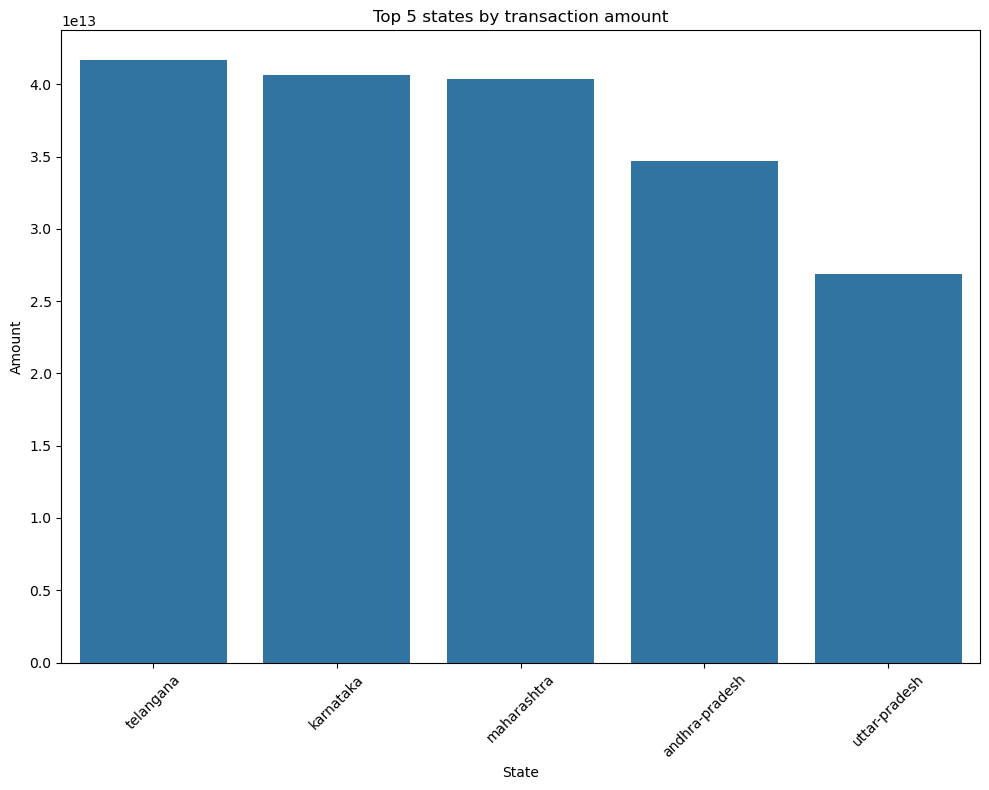

In [62]:
plt.figure(figsize=(10,8))
plt.title("Top 5 states by transaction amount")
sns.barplot(data=state_transaction,x='state',y='amount')
plt.xlabel('State')
plt.ylabel('Amount')
plt.xticks(rotation = 45)
plt.tight_layout()
plt.show()

##### Conclusion:  Telangana  has highest transaction amount with 4.165596e+13

In [63]:
# 2.total transaction amount by transaction type
transaction_type_amount = df.groupby('transaction_type')['amount'].sum().reset_index().sort_values(by='amount',ascending=False).head()
print(transaction_type_amount)


           transaction_type        amount
3     Peer-to-peer payments  5.330559e+14
1         Merchant payments  1.306800e+14
4  Recharge & bill payments  2.667758e+13
2                    Others  3.485623e+11
0        Financial Services  2.840397e+11


##### 1. Why did you pick the specific chart?
##### Pie chart
##### Because pie charts show: how much each category contributes to total

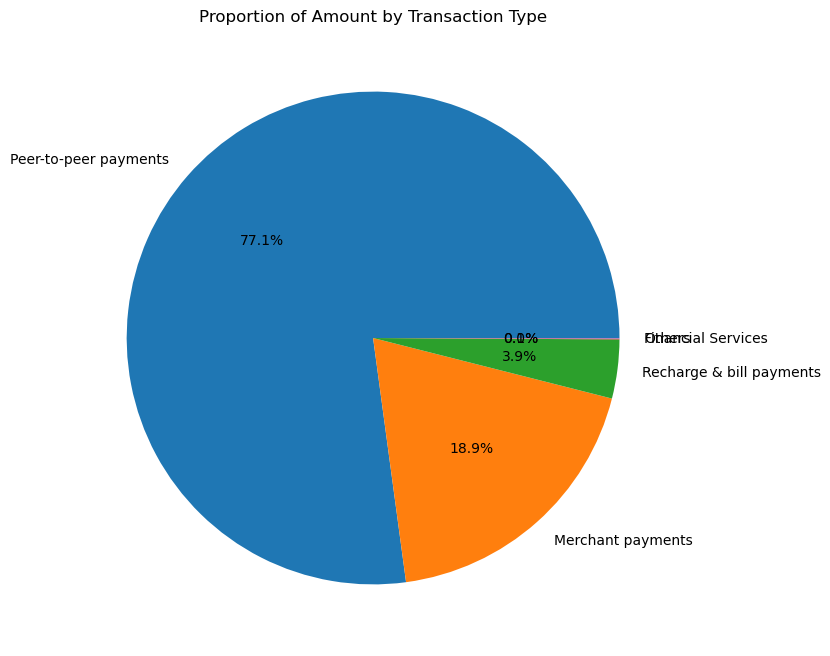

In [64]:
plt.figure(figsize=(8,8))
plt.title("Proportion of Amount by Transaction Type")
plt.pie(transaction_type_amount['amount'],labels=transaction_type_amount['transaction_type'],autopct='%1.1f%%')
plt.show()

##### Conclusion: 1.Peer-to-peer payments is top transaction type by amount. 

In [66]:
# 2.top transaction type by count
transaction_type_count = df.groupby('transaction_type')['count'].sum().reset_index().sort_values(by='count',ascending=False).head()
print(transaction_type_count)

           transaction_type         count
1         Merchant payments  260477833027
3     Peer-to-peer payments  170065177533
4  Recharge & bill payments   39193590614
2                    Others     524101110
0        Financial Services     308419161


##### 1. Why did you pick the specific chart?
##### Pie chart
##### Because pie charts show: how much each category contributes to total

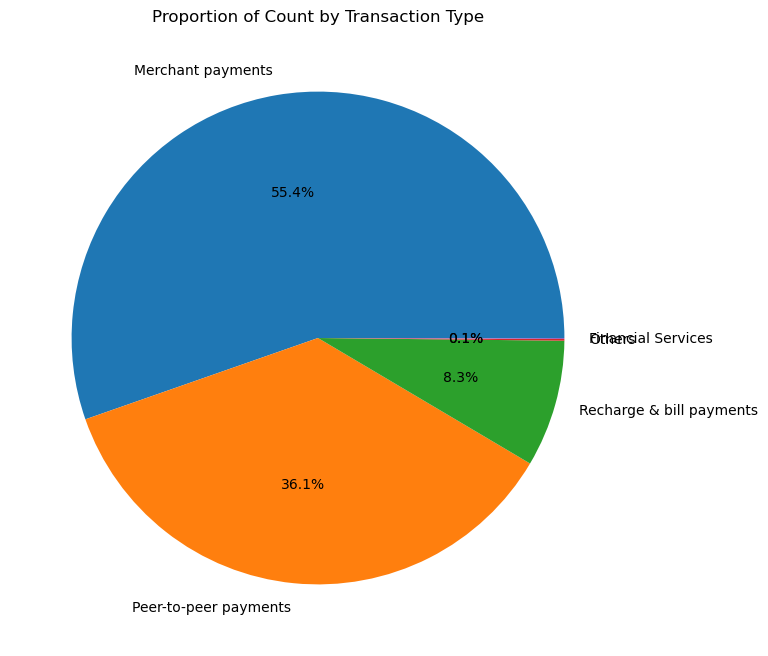

In [67]:
plt.figure(figsize=(8,8))
plt.title('Proportion of Count by Transaction Type')
plt.pie(transaction_type_count['count'],labels=transaction_type_count['transaction_type'],autopct='%1.1f%%')
plt.show()

##### Conclusion: 1.Merchant payments is top transaction type by count. 

In [132]:
#load the table aggregated users
query = "select * from aggregated_user"

df = pd.read_sql(query,load_ssql.conn)
print(df.head())

   level state  year  quarter    brand     count  percentage  \
0  india  None  2018        1   Xiaomi  11926334    0.254413   
1  india  None  2018        1  Samsung   9609401    0.204988   
2  india  None  2018        1     Vivo   5894293    0.125737   
3  india  None  2018        1     Oppo   4479351    0.095554   
4  india  None  2018        1   Realme   2376866    0.050703   

   registered_users  app_opens  
0          46877867          0  
1          46877867          0  
2          46877867          0  
3          46877867          0  
4          46877867          0  


C:\Users\NEHA\AppData\Local\Temp\ipykernel_15916\1314421092.py:4: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query,load_ssql.conn)


In [71]:
print(df.describe())

              year      quarter         count   percentage  registered_users  \
count  6919.000000  6919.000000  6.919000e+03  6919.000000      6.919000e+03   
mean   2019.647059     2.411765  1.000240e+06     0.090909      1.100264e+07   
std       1.233982     1.140713  4.589936e+06     0.083314      3.692268e+07   
min    2018.000000     1.000000  1.000000e+01     0.005158      5.010000e+02   
25%    2019.000000     1.000000  1.020550e+04     0.020542      2.042920e+05   
50%    2020.000000     2.000000  9.565800e+04     0.057649      2.185938e+06   
75%    2021.000000     3.000000  5.216465e+05     0.146133      9.233009e+06   
max    2022.000000     4.000000  8.842700e+07     0.478367      3.729518e+08   

          app_opens  
count  6.919000e+03  
mean   2.938519e+08  
std    1.248509e+09  
min    0.000000e+00  
25%    0.000000e+00  
50%    6.129766e+06  
75%    1.656051e+08  
max    1.572420e+10  


In [72]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6919 entries, 0 to 6918
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   level             6919 non-null   object 
 1   state             6732 non-null   object 
 2   year              6919 non-null   int64  
 3   quarter           6919 non-null   int64  
 4   brand             6919 non-null   object 
 5   count             6919 non-null   int64  
 6   percentage        6919 non-null   float64
 7   registered_users  6919 non-null   int64  
 8   app_opens         6919 non-null   int64  
dtypes: float64(1), int64(5), object(3)
memory usage: 486.6+ KB
None


In [73]:
df.shape

(6919, 9)

In [74]:
df.duplicated().sum()

np.int64(0)

In [75]:
#3.top mobile brand by aggregated user
top_mobile_brand = df.groupby('brand')['count'].sum().reset_index().sort_values(by='count',ascending=False).head()
print(top_mobile_brand)

      brand       count
19   Xiaomi  1739128584
16  Samsung  1343209247
18     Vivo  1250832199
13     Oppo   840501764
14   Others   579023847


##### 1. Why did you pick the specific chart?
##### Barplot
##### Because bar plots clearly show: highest value ,lowest value ,category comparison

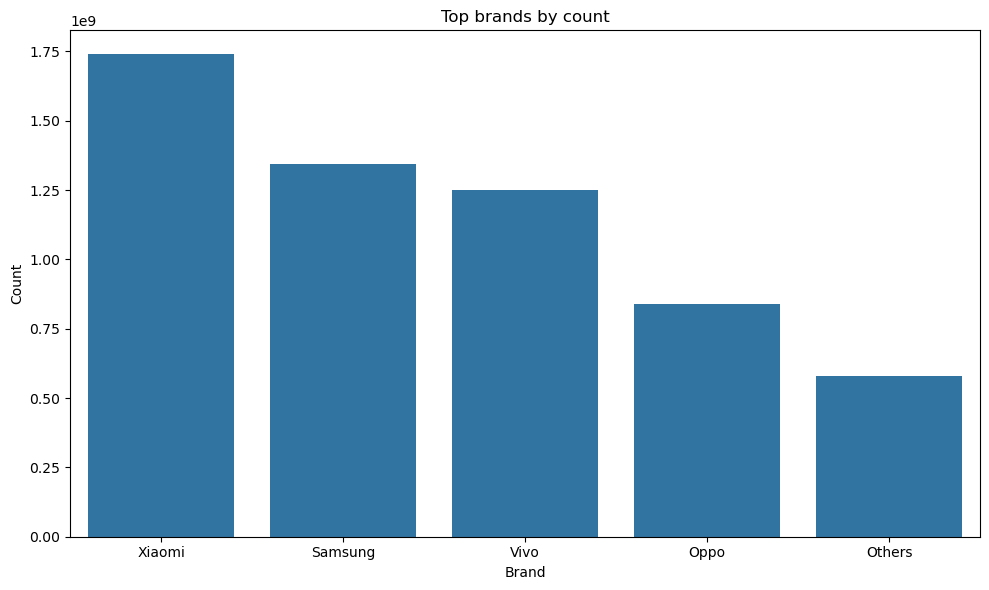

In [80]:
plt.figure(figsize=(10,6))
plt.title('Top brands by count')
sns.barplot(data=top_mobile_brand,x='brand',y='count')
plt.xlabel('brand'.title())
plt.ylabel('count'.title())
plt.tight_layout()
plt.show()

##### Conclusion: Xiaomi is top brand used by users.

##### 1. Why did you pick the specific chart?
##### Heatmap
##### Used to show correlation between numerical features.

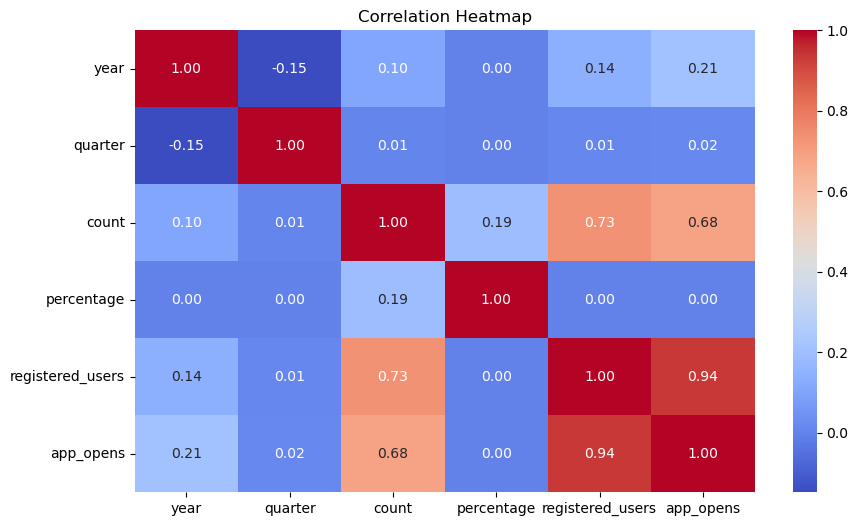

In [133]:
# Correlation matrix
correlation = df.corr(numeric_only=True)

# Plot heatmap
plt.figure(figsize=(10,6))

sns.heatmap(
    correlation,
    annot=True,        # show values
    cmap='coolwarm',   # colors
    fmt='.2f'          # 2 decimal values
)

plt.title("Correlation Heatmap")

plt.show()

#### Conclusion: 
#### 1.As registered users increase, app opens also increase heavily (0.94).
#### 2.Higher transaction counts happen where registered users are high (0.73).
#### 3.quarter has almost NO correlation.
#### 4.year has mild positive relation with app_opens (0.21).
#### 5.percentage has VERY LOW correlation.
#### 6.Users who open the app more tend to perform more transactions (0.68). 

In [134]:
query = 'select * from  aggregated_insurance;'

df = pd.read_sql(query,load_ssql.conn)
print(df)

     level        state  year  quarter insurance_type   count       amount
0    india         None  2020        2      Insurance  185348   33732166.0
1    india         None  2020        3      Insurance  354284   89495076.0
2    india         None  2020        4      Insurance  248626  170979933.0
3    india         None  2021        1      Insurance  318119  206307024.0
4    india         None  2021        2      Insurance  363989  295066678.0
..     ...          ...   ...      ...            ...     ...          ...
696  state  west-bengal  2023        4      Insurance   72712  100365562.0
697  state  west-bengal  2024        1      Insurance   79576  104987909.0
698  state  west-bengal  2024        2      Insurance   67048   89476633.0
699  state  west-bengal  2024        3      Insurance   77158  107451766.0
700  state  west-bengal  2024        4      Insurance   91719  120602777.0

[701 rows x 7 columns]


C:\Users\NEHA\AppData\Local\Temp\ipykernel_15916\3297264083.py:3: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query,load_ssql.conn)


In [135]:
#aggregated insurance
#top aggregate insurance by count
top_states_by_insurance = df.groupby('state')['count'].sum().reset_index().sort_values(by='count',ascending=False).head()
print(top_states_by_insurance)

            state    count
15      karnataka  1957404
20    maharashtra  1815539
30     tamil-nadu  1215269
33  uttar-pradesh  1139153
31      telangana   894342


##### 1. Why did you pick the specific chart?
##### Barplot
##### Because bar plots clearly show: highest value ,lowest value ,category comparison

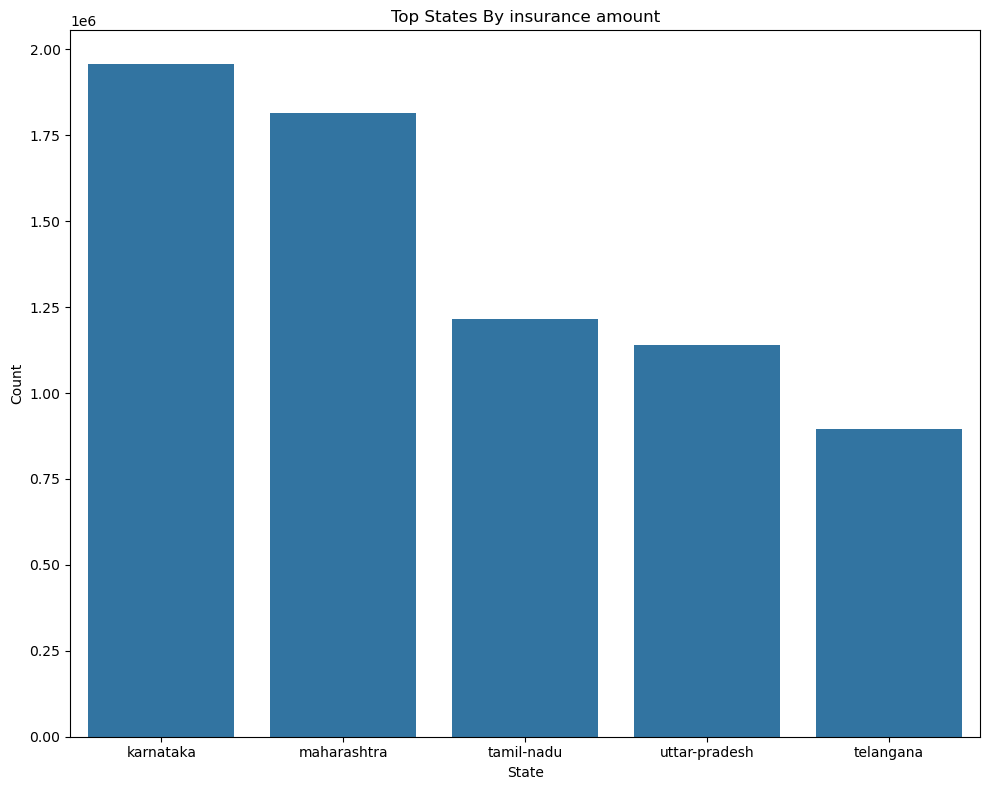

In [136]:
plt.figure(figsize=(10,8))
plt.title("Top States By insurance amount")
sns.barplot(data=top_states_by_insurance,x='state',y='count')
plt.xlabel('State')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

#### Conclusion: Karnataka is the top state by insurance count.

In [91]:
#yearwise insurance amount increase
yearwise_amount = df.groupby('year')['amount'].sum().reset_index().sort_values(by='amount',ascending=False).head()
print(yearwise_amount)

   year        amount
4  2024  1.585356e+10
3  2023  1.211334e+10
2  2022  8.477806e+09
1  2021  2.998379e+09
0  2020  5.884144e+08


##### 1. Why did you pick the specific chart?
##### Histogram
##### Frequency distribution of a numerical variable.

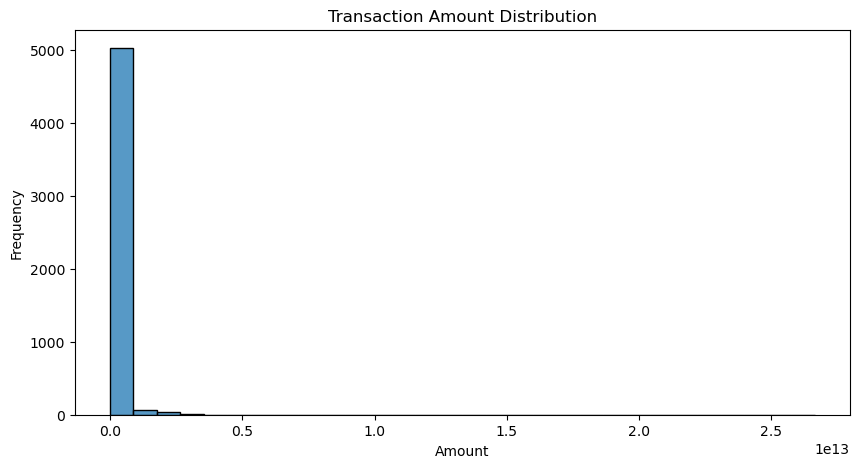

In [32]:
plt.figure(figsize=(10,5))

sns.histplot(

    df['amount'],

    bins=30

)

plt.title("Transaction Amount Distribution")

plt.xlabel("Amount")

plt.ylabel("Frequency")

plt.show()

#### Conclusion:this is a highly positively skewed (right-skewed) distribution.
##### Histogram shows:
#### The transaction amount distribution is highly positively skewed,
#### indicating that most transactions are of smaller amounts,
#### while a few transactions have extremely high values.

##### 1. Why did you pick the specific chart?
##### Line plot
##### Used to show trends over time or sequential data.

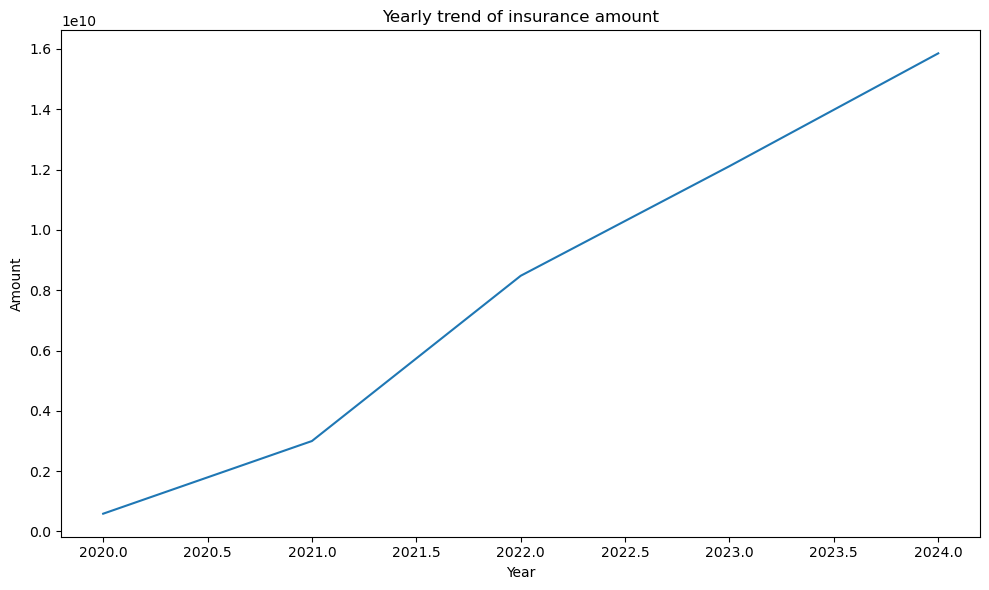

In [92]:
plt.figure(figsize=(10,6))
plt.title('Yearly trend of insurance amount')
sns.lineplot(data=yearwise_amount,x='year',y='amount')
plt.xlabel('Year')
plt.ylabel('Amount')
plt.tight_layout()
plt.show()

#### Conclusion: Yearly trend of insurance amount is increasing.

In [93]:
query = 'select * from map_insurance;'
df = pd.read_sql(query,load_ssql.conn)
print(df)

C:\Users\NEHA\AppData\Local\Temp\ipykernel_15916\2065837533.py:2: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query,load_ssql.conn)


         level        state  year  quarter  latitude  longitude  metric  \
0        india         None  2020        2      13.0       78.0    4720   
1        india         None  2020        2      17.0       78.0    3186   
2        india         None  2020        2      13.0       77.0    2753   
3        india         None  2020        2      17.0       78.0    2674   
4        india         None  2020        2      13.0       78.0    2408   
...        ...          ...   ...      ...       ...        ...     ...   
1430344  state  west-bengal  2024        4      23.0       87.0       1   
1430345  state  west-bengal  2024        4      23.0       87.0       1   
1430346  state  west-bengal  2024        4      24.0       87.0       1   
1430347  state  west-bengal  2024        4      27.0       90.0       1   
1430348  state  west-bengal  2024        4      27.0       89.0       1   

                              label  
0                         karnataka  
1                      

In [29]:
#map insurance
#average metric
avg_metric = df['metric'].mean()
avg_metric

np.float64(18.41689895263324)

##### Conclusion: Average metric of map insurance is 18.416

In [94]:
metric_by_label = df.groupby('label')['metric'].sum().reset_index().sort_values(by='label',ascending=False).head()
print(metric_by_label)

                    label  metric
877    zunheboto district      56
876          ysr district   32560
875     yavatmal district   12411
874        yanam district     565
873  yamunanagar district   11372


##### 1. Why did you pick the specific chart?
##### Pie chart
##### Because pie charts show: how much each category contributes to total

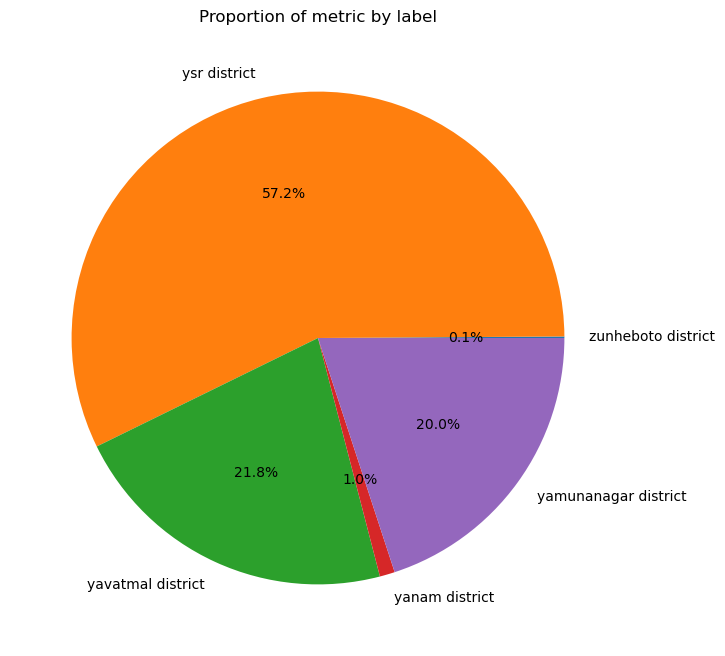

In [96]:
plt.figure(figsize=(8,8))
plt.title('Proportion of metric by label')
plt.pie(metric_by_label['metric'],labels=metric_by_label['label'],autopct='%1.1f%%')
plt.show()

##### Conclusion: ysr district is having major 57.2% proportion.

In [100]:
query = 'select * from map_transaction;'
df = pd.read_sql(query,load_ssql.conn)

C:\Users\NEHA\AppData\Local\Temp\ipykernel_15916\2931806950.py:2: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query,load_ssql.conn)


In [102]:
#map transaction
regionwise_transaction = df.groupby('region_name')['amount'].sum().reset_index().sort_values(by='amount',ascending=False).head()
print(regionwise_transaction)


       region_name        amount
20     maharashtra  1.103295e+11
33   uttar pradesh  7.667229e+10
1   andhra pradesh  7.059824e+10
30      tamil nadu  6.071749e+10
15       karnataka  5.273348e+10


##### 1. Why did you pick the specific chart?
##### Pie chart
##### Because pie charts show: how much each category contributes to total

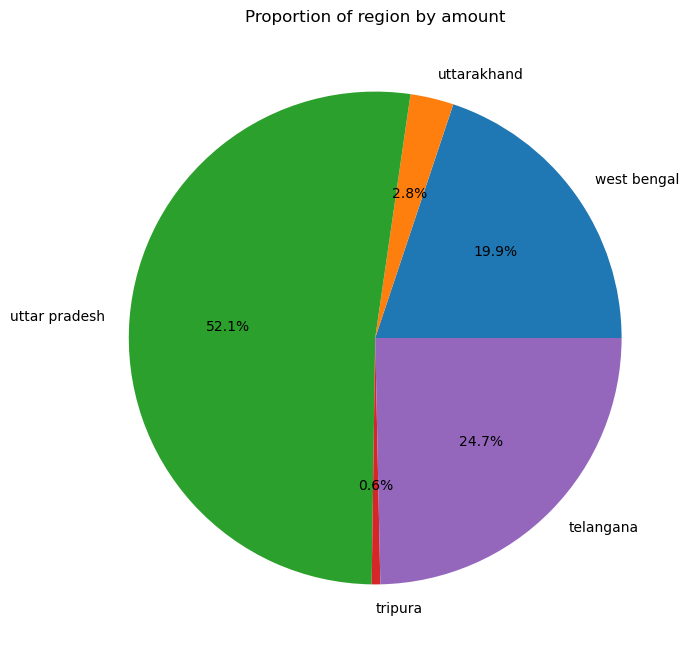

In [99]:
plt.figure(figsize=(8,8))
plt.title('Proportion of region by amount')
plt.pie(regionwise_transaction['amount'],labels=regionwise_transaction['region_name'],autopct='%1.1f%%')
plt.show()

#### Conclusion: Uttarpradesh is top region by amount

In [113]:
#map user 
query = 'select * from map_user;'
df  = pd.read_sql(query,load_ssql.conn)

C:\Users\NEHA\AppData\Local\Temp\ipykernel_15916\455373543.py:3: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df  = pd.read_sql(query,load_ssql.conn)


In [114]:
#registered users with region
regionwise_users = df.groupby('region_name')['registered_users'].sum().reset_index().sort_values(by='region_name',ascending=False).head()
print(regionwise_users)


              region_name  registered_users
878    zunheboto district            180620
877          ysr district          30313329
876     yavatmal district          13114293
875        yanam district            396163
874  yamunanagar district           8073826


##### 1. Why did you pick the specific chart?
##### Barplot
##### Because bar plots clearly show: highest value ,lowest value ,category comparison

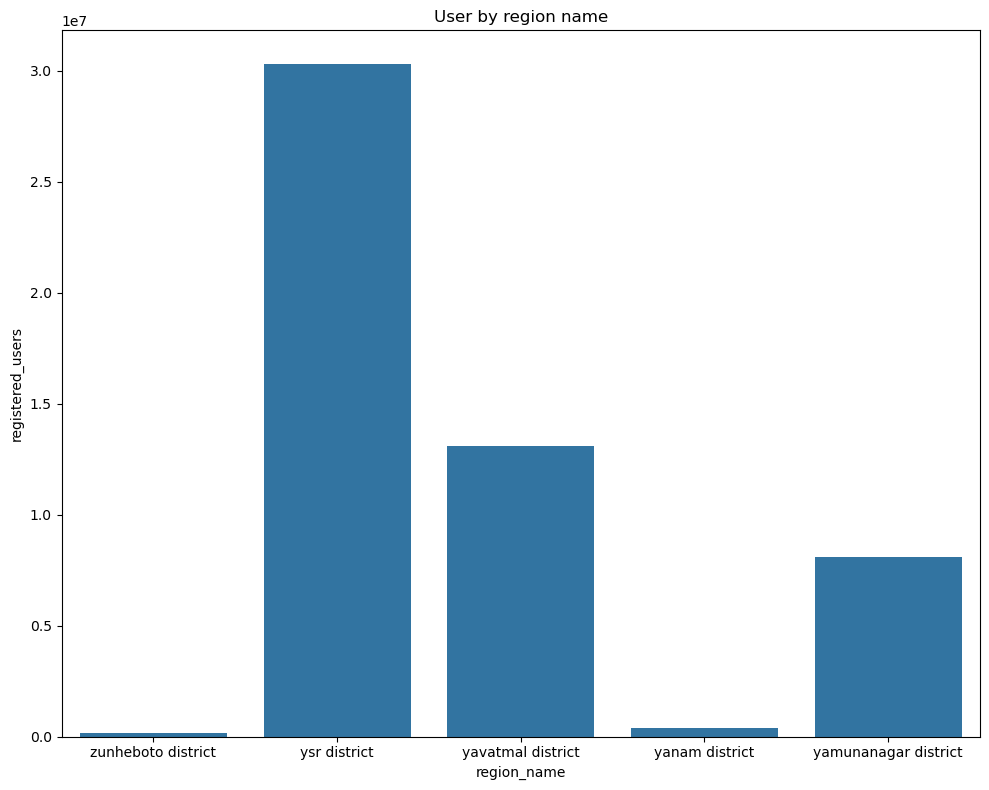

In [116]:
plt.figure(figsize=(10,8))
plt.title("User by region name")
sns.barplot(data=regionwise_users,x='region_name',y='registered_users')
plt.xlabel('region_name')
plt.ylabel('registered_users')
plt.tight_layout()
plt.show()


#### Conclusion: Ysr district is top region wise.

In [117]:
#top transaction 
query = 'select * from top_transaction;'

df = pd.read_sql(query,load_ssql.conn)

C:\Users\NEHA\AppData\Local\Temp\ipykernel_15916\3073626260.py:4: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query,load_ssql.conn)


In [119]:
#top tansaction amount

top_state_amount = df.groupby('state')['amount'].sum().reset_index().sort_values(by='amount',ascending=False).head()
print(top_state_amount)

             state        amount
31       telangana  4.334496e+13
15       karnataka  3.749980e+13
20     maharashtra  3.475058e+13
1   andhra-pradesh  3.128970e+13
28       rajasthan  2.235769e+13


##### 1. Why did you pick the specific chart?
##### Barplot
##### Because bar plots clearly show: highest value ,lowest value ,category comparison

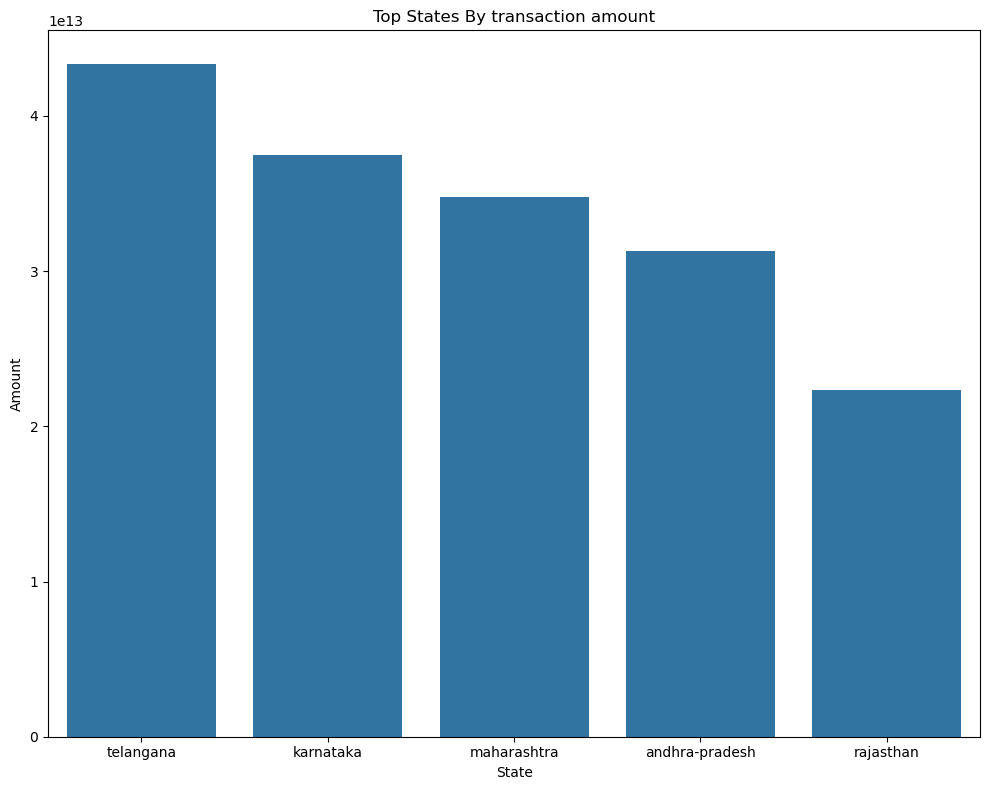

In [123]:
plt.figure(figsize=(10,8))
plt.title("Top States By transaction amount")
sns.barplot(data=top_state_amount,x='state',y='amount')
plt.xlabel('State')
plt.ylabel('Amount')
plt.tight_layout()
plt.show()

#### Conclusion: Telangana is the top state in transaction amount

In [124]:
#top user
query = 'select * from top_user;'
df = pd.read_sql(query,load_ssql.conn)


C:\Users\NEHA\AppData\Local\Temp\ipykernel_15916\3396179182.py:3: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query,load_ssql.conn)


In [125]:
#resgistered user by state 
top_user_state = df.groupby('state')['registered_users'].sum().reset_index().sort_values(by='registered_users',ascending=False).head()
print(top_user_state)

             state  registered_users
20     maharashtra         843716111
15       karnataka         595858325
1   andhra-pradesh         504044931
33   uttar-pradesh         467294697
31       telangana         447484937


##### 1. Why did you pick the specific chart?
##### Barplot|
##### Because bar plots clearly show: highest value ,lowest value ,category comparison

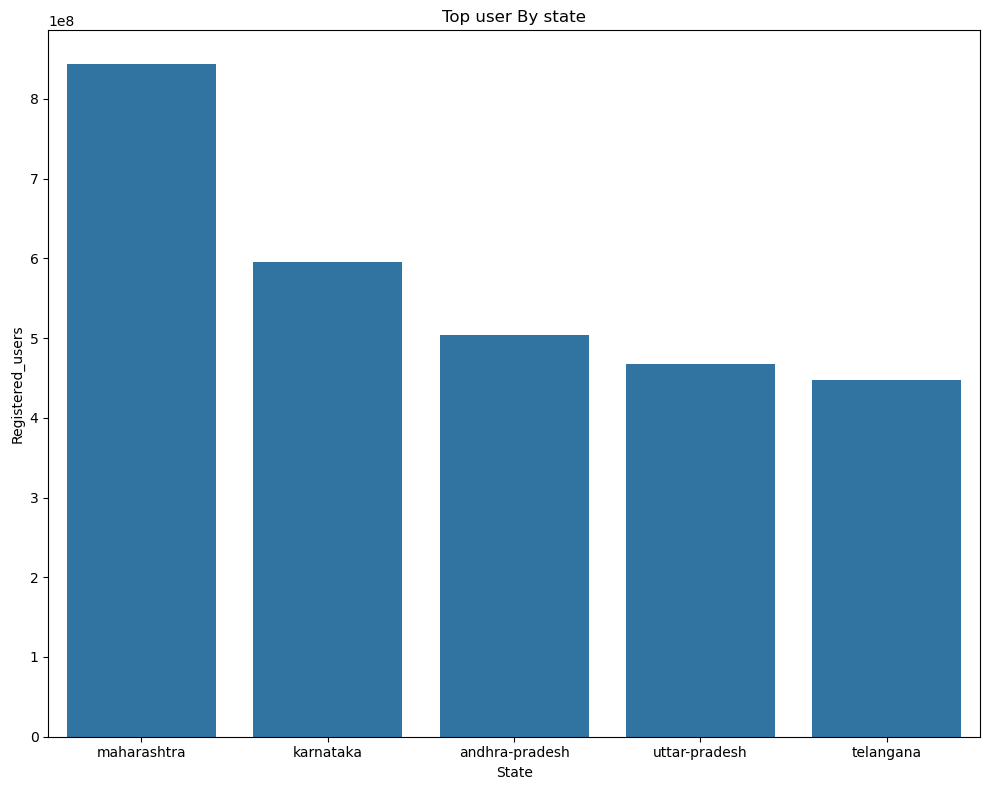

In [127]:
plt.figure(figsize=(10,8))
plt.title("Top user By state")
sns.barplot(data=top_user_state,x='state',y='registered_users')
plt.xlabel('State')
plt.ylabel('Registered_users')
plt.tight_layout()
plt.show()

#### Conclusion: Maharashtra is the top state in registered users.

In [128]:
# top insurance
query = 'select * from top_insurance;'
df = pd.read_sql(query,load_ssql.conn)

C:\Users\NEHA\AppData\Local\Temp\ipykernel_15916\1858925574.py:3: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query,load_ssql.conn)


In [129]:
#top state wise average count -
state_wise_avg_count = df.groupby('state')['count'].mean().reset_index().sort_values(by='count',ascending=False).head()
print(state_wise_avg_count)

          state        count
15    karnataka  4994.913158
20  maharashtra  4218.968421
30   tamil-nadu  2679.136842
31    telangana  2400.584211
8         delhi  2114.523684


##### 1. Why did you pick the specific chart?
##### Pie Chart - 
##### Because pie charts show: how much each category contributes to total

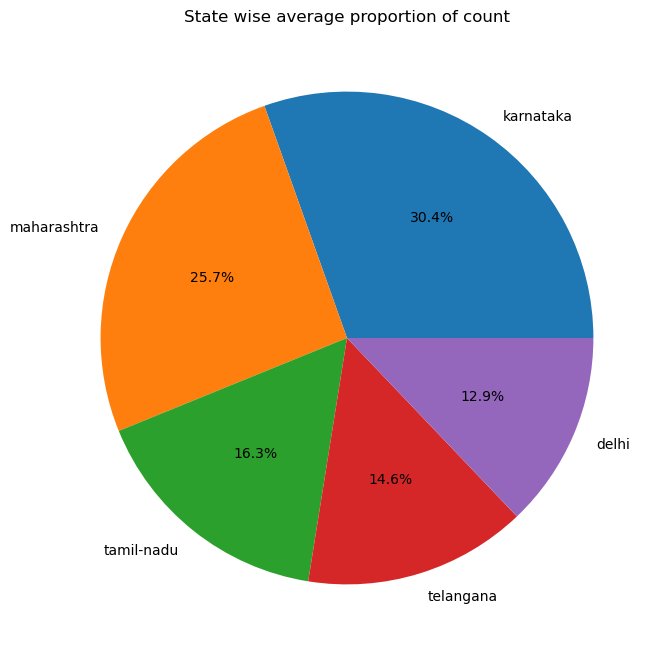

In [131]:
plt.figure(figsize=(8,8))
plt.title('State wise average proportion of count')
plt.pie(state_wise_avg_count['count'],labels=state_wise_avg_count['state'],autopct='%1.1f%%')
plt.show()

##### Conclusion: Karnataka is average state in purachasing insurance.

##### 1. Why did you pick the specific chart?
##### Pair Plot
##### Used to compare relationships among multiple numerical features together.

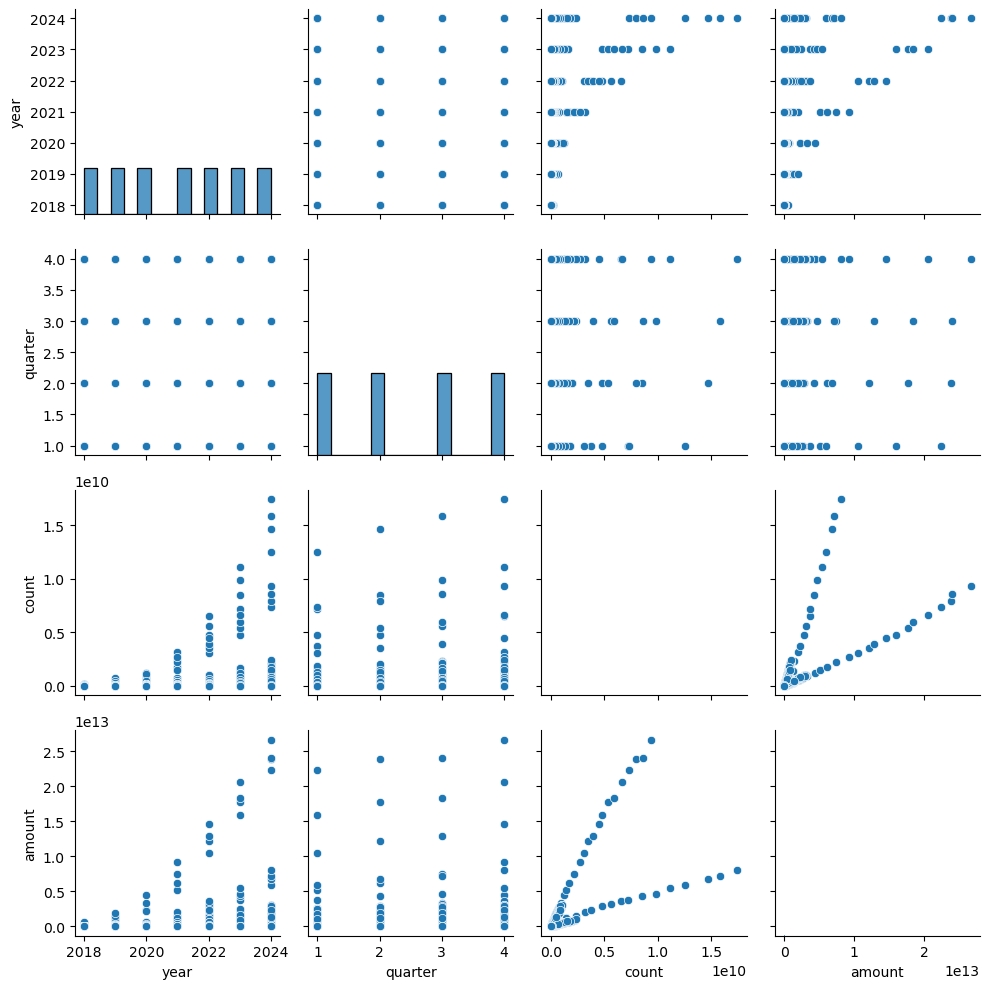

In [31]:
sns.pairplot(df)
plt.tight_layout()
plt.show()

#### Model Building

In [13]:
import pandas as pd
import numpy as np

# visualization
import matplotlib.pyplot as plt
import seaborn as sns

# preprocessing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# models
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor

# evaluation
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

# hyperparameter tuning
from sklearn.model_selection import RandomizedSearchCV
from sklearn.model_selection import cross_val_score

# save model
import joblib

In [14]:
#load the dataset
df = pd.read_csv('aggregated_transaction_combined.csv')
print("Top rows:\n",df.head())
print("Bottom rows:\n",df.tail())


Top rows:
    level state  year  quarter          transaction_type     count  \
0  india   NaN  2018        1  Recharge & bill payments  72550406   
1  india   NaN  2018        1     Peer-to-peer payments  46982705   
2  india   NaN  2018        1         Merchant payments   5368669   
3  india   NaN  2018        1        Financial Services   3762820   
4  india   NaN  2018        1                    Others   5761576   

         amount  
0  1.447271e+10  
1  1.472459e+11  
2  4.656679e+09  
3  8.158531e+08  
4  4.643217e+09  
Bottom rows:
       level        state  year  quarter          transaction_type      count  \
5169  state  west-bengal  2024        4         Merchant payments  655100809   
5170  state  west-bengal  2024        4     Peer-to-peer payments  493217788   
5171  state  west-bengal  2024        4  Recharge & bill payments   76043195   
5172  state  west-bengal  2024        4        Financial Services    2352084   
5173  state  west-bengal  2024        4             

In [15]:
#Basic Dataset Check
print("The dataset shape:",df.shape,"\n")

print("The dataset column name:",df.columns,'\n')

print("The dataset basic information:",df.info(),'\n')

print("The basic stats summary:",df.describe(),'\n')

The dataset shape: (5174, 7) 

The dataset column name: Index(['level', 'state', 'year', 'quarter', 'transaction_type', 'count',
       'amount'],
      dtype='object') 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5174 entries, 0 to 5173
Data columns (total 7 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   level             5174 non-null   object 
 1   state             5034 non-null   object 
 2   year              5174 non-null   int64  
 3   quarter           5174 non-null   int64  
 4   transaction_type  5174 non-null   object 
 5   count             5174 non-null   int64  
 6   amount            5174 non-null   float64
dtypes: float64(1), int64(3), object(3)
memory usage: 283.1+ KB
The dataset basic information: None 

The basic stats summary:               year      quarter         count        amount
count  5174.000000  5174.000000  5.174000e+03  5.174000e+03
mean   2021.002513     2.500773  9.094881e+07  1.3356

## ***5. Hypothesis Testing***

### Based on your chart experiments, define three hypothetical statements from the dataset. In the next three questions, perform hypothesis testing to obtain final conclusion about the statements through your code and statistical testing.

In [16]:
from scipy.stats import ttest_ind
from scipy.stats import pearsonr
from scipy.stats import f_oneway

### Hypothetical Statement - 1 
### Merchant payments have higher transaction amounts than Recharge & Bill payments.

#### 1. State Your research hypothesis as a null hypothesis and alternate hypothesis.

Null Hypothesis (H₀) : There is no significant difference in transaction amount
between Merchant payments and Recharge & Bill payments.

Alternate Hypothesis (H₁) : Merchant payments have significantly higher transaction amounts
than Recharge & Bill payments.

#### 2. Perform an appropriate statistical test.

In [17]:
df.columns

Index(['level', 'state', 'year', 'quarter', 'transaction_type', 'count',
       'amount'],
      dtype='object')

In [18]:
# Perform Statistical Test to obtain P-Value
merchant = df[df['transaction_type'] == 'Merchant Payments']['amount']
recharge = df[df['transaction_type'] == 'Recharge & Bill Payments']['amount']

In [19]:
t_stat ,p_value = ttest_ind(merchant,recharge)

print('T_Statistic:',t_stat)
print('P_Value:',p_value)

T_Statistic: nan
P_Value: nan


c:\Users\NEHA\anaconda3\Lib\site-packages\scipy\_lib\deprecation.py:234: SmallSampleWarning: One or more sample arguments is too small; all returned values will be NaN. See documentation for sample size requirements.
  return f(*args, **kwargs)


##### Which statistical test have you done to obtain P-Value?

Independent T-Test 

In [20]:
if p_value < 0.05:
    print("Reject Null Hypothesis")
else:
    print("Fail to Reject Null Hypothesis")

Fail to Reject Null Hypothesis


#### Conclusion: There is no statistically significant difference between Merchant payments and Recharge & Bill payments based on the available dataset.

##### Why did you choose the specific statistical test?

Why T-Test?
Because:
comparing means of TWO independent groups
numerical target variable (amount)
checking whether difference is statistically significant

 ### Hypothetical Statement - 2 
 ### Registered users and app opens are positively correlated.

#### 1. State Your research hypothesis as a null hypothesis and alternate hypothesis.

Null Hypothesis (H₀) : There is no relationship between registered users and app opens.

Alternate Hypothesis (H₁) : There is a significant positive relationship between registered users and app opens.


#### 2. Perform an appropriate statistical test.

In [21]:
# Perform Statistical Test to obtain P-Value
user_df = pd.read_csv('aggregated_user_combined.csv')

user_df.columns

Index(['level', 'state', 'year', 'quarter', 'brand', 'count', 'percentage',
       'registered_users', 'app_opens'],
      dtype='object')

In [22]:
corr , p_value = pearsonr(
    user_df['registered_users'],
    user_df['app_opens']
)

print('Correlation:',corr)
print('P_Value',p_value)

Correlation: 0.9361809518465026
P_Value 0.0


In [23]:
if p_value < 0.05:
    print('Reject Null Hypothese.')
else:
    print('Fail to reject the null hypothesis.')

Reject Null Hypothese.


##### Conclusion: We reject the null hypotheesis & we concluded that there is strong correlation between registered users & app_opens.

##### Which statistical test have you done to obtain P-Value?

#### Pearson Correlation Test

##### Why did you choose the specific statistical test?

Why Pearson Test?

Because:

both variables are numerical
checking linear relationship
measuring correlation strength

### Hypothetical Statement - 3 
### Transaction amounts differ significantly across different states.

#### 1. State Your research hypothesis as a null hypothesis and alternate hypothesis.

Null Hypothesis (H₀) : Average transaction amount is same across all states.

Alternate Hypothesis (H₁) : Average transaction amount differs significantly across states.

#### 2. Perform an appropriate statistical test.

In [25]:
# Perform Statistical Test to obtain P-Value
state_groups = []

top_states = df['state'].dropna().unique()[:5]

for state in top_states:
    state_amount = df[df['state'] == state]['amount']
    state_groups.append(state_amount)

f_stat , p_value = f_oneway(*state_groups)

print('F-statistic:',f_stat)
print('P-Value',p_value)

F-statistic: 18.900531075216428
P-Value 9.150366958888143e-15


In [26]:
if p_value < 0.05:
    print('Reject Null Hypothesis.')
else:
    print('Fail to reject the null hypothesis.')

Reject Null Hypothesis.


#### Conclusion: Reject Null Hypothesis, so we accept the alternative hypothesis that Average transaction amount differs significantly across states.

##### Which statistical test have you done to obtain P-Value?

ANOVA Test

##### Why did you choose the specific statistical test?

Why ANOVA?

Because:

comparing MORE THAN TWO groups
multiple states
numerical target (amount)

## ***6. Feature Engineering & Data Pre-processing***

### 1. Handling Missing Values

In [9]:
#Null Value Check
print(df.isnull().sum())

level                 0
state               140
year                  0
quarter               0
transaction_type      0
count                 0
amount                0
dtype: int64


In [10]:
# Handling Missing Values & Missing Value Imputation
df['state']=df['state'].fillna('No State')

In [42]:
df['state'].unique()

array(['No State', 'andaman-&-nicobar-islands', 'andhra-pradesh',
       'arunachal-pradesh', 'assam', 'bihar', 'chandigarh',
       'chhattisgarh', 'dadra-&-nagar-haveli-&-daman-&-diu', 'delhi',
       'goa', 'gujarat', 'haryana', 'himachal-pradesh', 'jammu-&-kashmir',
       'jharkhand', 'karnataka', 'kerala', 'ladakh', 'lakshadweep',
       'madhya-pradesh', 'maharashtra', 'manipur', 'meghalaya', 'mizoram',
       'nagaland', 'odisha', 'puducherry', 'punjab', 'rajasthan',
       'sikkim', 'tamil-nadu', 'telangana', 'tripura', 'uttar-pradesh',
       'uttarakhand', 'west-bengal'], dtype=object)

In [12]:
df['state']=df['state'].replace('No State','All India')

#### What all missing value imputation techniques have you used and why did you use those techniques?

Used fillna() to fill nan

In [11]:
print(df.isnull().sum())

level               0
state               0
year                0
quarter             0
transaction_type    0
count               0
amount              0
dtype: int64


In [13]:
print(df.head())
print(df.tail())

   level     state  year  quarter          transaction_type     count  \
0  india  No State  2018        1  Recharge & bill payments  72550406   
1  india  No State  2018        1     Peer-to-peer payments  46982705   
2  india  No State  2018        1         Merchant payments   5368669   
3  india  No State  2018        1        Financial Services   3762820   
4  india  No State  2018        1                    Others   5761576   

         amount  
0  1.447271e+10  
1  1.472459e+11  
2  4.656679e+09  
3  8.158531e+08  
4  4.643217e+09  
      level        state  year  quarter          transaction_type      count  \
5169  state  west-bengal  2024        4         Merchant payments  655100809   
5170  state  west-bengal  2024        4     Peer-to-peer payments  493217788   
5171  state  west-bengal  2024        4  Recharge & bill payments   76043195   
5172  state  west-bengal  2024        4        Financial Services    2352084   
5173  state  west-bengal  2024        4              

In [14]:
#duplicate check
df.duplicated().sum()

np.int64(0)

### 2. Handling Outliers

In [ ]:
# Handling Outliers & Outlier treatments

##### What all outlier treatment techniques have you used and why did you use those techniques?

##### No outliers detected

### 3. Categorical Encoding

In [16]:
# Encode your categorical columns
categorical_cols = ['state', 'transaction_type']

numerical_cols = ['year', 'quarter', 'count']

### 4. Feature Manipulation & Selection

#### 1. Feature Manipulation

In [17]:
df['avg_transaction'] = df['amount'] / df['count']

#### 2. Feature Selection

In [18]:
#x feature
X = df[['state',
        'year',
        'quarter',
        'transaction_type',
        'count']]

In [19]:
#target
y = df['amount']

##### What all feature selection methods have you used  and why? ##### Which all features you found important and why?

#### state , year ,quarter , transaction selected to predict the future transaction amount. these variable play very much important role in predicting.

### 5. Data Transformation

#### Do you think that your data needs to be transformed? If yes, which transformation have you used. Explain Why?

#### No.

### 6. Data Scaling

In [20]:
preprocessor = ColumnTransformer(

    transformers=[

        ('cat',
         OneHotEncoder(handle_unknown='ignore'),
         categorical_cols),

        ('num',
         StandardScaler(),
         numerical_cols)

    ]
)

#### What all categorical encoding techniques have you used & why did you use those techniques?

In this project, categorical encoding techniques were used to convert categorical features into numerical format because machine learning algorithms cannot directly understand text or string values.

The dataset contained categorical columns such as:
- state
- transaction_type

To handle these features, One-Hot Encoding was used.

One-Hot Encoding creates separate binary columns for each category. For example, the 'state' column was converted into multiple columns such as:
- state_bihar
- state_karnataka
- state_maharashtra

Similarly, the transaction_type column was transformed into:
- transaction_type_Peer-to-peer payments
- transaction_type_Merchant payments
- transaction_type_Recharge & bill payments

This technique was chosen because the categorical variables in the dataset are nominal categories, meaning they do not have any natural order or ranking. One-Hot Encoding prevents the model from assuming any ordinal relationship between categories.

I used One-Hot Encoding through ColumnTransformer and OneHotEncoder in Scikit-learn as part of the preprocessing pipeline. This ensured proper transformation during both training and prediction stages.

Why One-Hot Encoding was used:
1. Machine learning models require numerical input.
2. The categorical features had no ordinal relationship.
3. It avoids introducing false numerical importance.
4. It works effectively with regression models such as Linear Regression, Random Forest, and XGBoost.

Additionally, numerical features such as:
- year
- quarter
- count

were passed through scaling pipelines where required.

Overall, One-Hot Encoding helped improve model compatibility, maintain feature integrity, and enhance prediction performance.

##### Which method have you used to scale you data and why?

In this project, StandardScaler was used for feature scaling of numerical variables.

The numerical columns included:
- year
- quarter
- count

Feature scaling was important because the dataset contained features with different value ranges. For example, transaction count values were very large compared to year and quarter values. Without scaling, machine learning algorithms may give more importance to larger numerical values, which can negatively affect model performance.

StandardScaler standardizes the data by transforming it into a distribution with:
- Mean = 0
- Standard Deviation = 1

The formula used by StandardScaler is:

z = (x - mean) / standard deviation

StandardScaler was chosen because:
1. It improves model convergence and stability.
2. It helps algorithms interpret features on the same scale.
3. It reduces bias caused by large numerical ranges.
4. It is highly effective for regression algorithms such as Linear Regression and XGBoost.

Scaling was applied using Scikit-learn pipelines along with ColumnTransformer to ensure proper preprocessing during both training and prediction phases.

Although tree-based models like Random Forest and XGBoost are less sensitive to scaling, scaling was still applied to maintain preprocessing consistency across all machine learning models used in the project.

### 7. Dimesionality Reduction

##### Do you think that dimensionality reduction is needed? Explain Why?

#### No very few features , no high-dimensional data

##### Which dimensionality reduction technique have you used and why? (If dimensionality reduction done on dataset.)

### 8. Data Splitting

In [21]:
X_train, X_test, y_train, y_test = train_test_split(

    X,
    y,

    test_size=0.2,

    random_state=42
)

##### What data splitting ratio have you used and why?

In this project, an 80:20 train-test split ratio was used for dividing the dataset into training and testing sets.

- 80% of the data was used for training the machine learning models.
- 20% of the data was used for testing and evaluating model performance on unseen data.

The split was implemented using Scikit-learn’s train_test_split() function.

This ratio was chosen because it provides a good balance between:
1. Sufficient training data for the model to learn patterns effectively.
2. Enough testing data to evaluate the model’s generalization capability accurately.

Using too little training data can lead to underfitting, while using too little testing data may produce unreliable evaluation results. The 80:20 ratio is widely accepted as a standard practice in machine learning projects because it ensures stable model training and fair performance evaluation.

Additionally, a random_state parameter was used to ensure reproducibility of results, meaning the same train-test split can be generated consistently across multiple runs.

### 9. Handling Imbalanced Dataset

##### Do you think the dataset is imbalanced? Explain Why.

This project is based on a regression problem where the target variable is transaction amount. Since regression tasks predict continuous numerical values rather than discrete class labels, the concept of class imbalance does not directly apply in the same way as classification problems.

However, during Exploratory Data Analysis (EDA), the transaction amount distribution was found to be highly right-skewed. Most transactions were concentrated around smaller values, while a few transactions had extremely large values. This indicates the presence of skewness and outliers rather than class imbalance.

The histogram and KDE plots showed that:
- a large number of transactions belonged to lower amount ranges
- only a small number of transactions had very high transaction amounts

Because of this skewed distribution:
1. Log transformation was applied to reduce skewness.
2. Data preprocessing and scaling techniques were used to stabilize the distribution.
3. Robust machine learning models such as Random Forest and XGBoost were implemented because they handle skewed and non-linear data more effectively.

Therefore, while the dataset is not “imbalanced” in a classification sense, it does contain skewed numerical distributions and high-value outliers that required preprocessing and transformation before model training.

In [ ]:
# Handling Imbalanced Dataset (If needed)

##### What technique did you use to handle the imbalance dataset and why? (If needed to be balanced)

Answer Here.

## ***7. ML Model Implementation***

### ML Model - 1 Linear Regression

In [22]:
# ML Model - 1 Implementation
lr_pipeline = Pipeline([

    ('preprocessor', preprocessor),

    ('model', LinearRegression())

])
# Fit the Algorithm
lr_pipeline.fit(X_train, y_train)

# Predict on the model
y_pred_lr = lr_pipeline.predict(X_test)


#### 1. Explain the ML Model used and it's performance using Evaluation metric Score Chart.

In [23]:
# Visualizing evaluation Metric Score chart
mae_lr = mean_absolute_error(y_test, y_pred_lr)

rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr))

r2_lr = r2_score(y_test, y_pred_lr)

print("Linear Regression")

print("MAE :", mae_lr)

print("RMSE :", rmse_lr)

print("R2 Score :", r2_lr)

Linear Regression
MAE : 194850082492.7895
RMSE : 784041908994.9321
R2 Score : 0.22112894625999013


#### 2. Cross- Validation & Hyperparameter Tuning

In [24]:
# ML Model - 1 Implementation with hyperparameter optimization techniques (i.e., GridSearch CV, RandomSearch CV, Bayesian Optimization etc.)

# Fit the Algorithm

# Predict on the model
cv_scores_lr = cross_val_score(

    lr_pipeline,

    X,
    y,

    cv=5,

    scoring='r2'
)

print(cv_scores_lr)

print(cv_scores_lr.mean())

[ 0.48565706 -1.4987684   0.52040352 -3.22135061  0.59843732]
-0.6231242234761066


##### Which hyperparameter optimization technique have you used and why?

For Model 1, GridSearchCV was used as the hyperparameter optimization technique.

GridSearchCV systematically searches through multiple combinations of hyperparameter values and selects the best-performing combination based on cross-validation performance. It evaluates every possible parameter combination specified in the parameter grid.

In this project, GridSearchCV was chosen because:
1. It provides an exhaustive and reliable search for optimal hyperparameters.
2. It improves model generalization and reduces overfitting.
3. It works effectively for tuning regression models.
4. It integrates well with Scikit-learn pipelines and cross-validation.

Cross-validation was performed using 5-fold Cross Validation with R² score as the evaluation metric. The dataset was divided into 5 folds, where the model was trained on 4 folds and validated on the remaining fold repeatedly. The average R² score was then calculated.

The evaluation metric considered for optimization was:
- R² Score

R² Score was selected because it measures how well the independent variables explain the variance in the target variable (transaction amount). A higher R² score indicates better predictive performance.


##### Have you seen any improvement? Note down the improvement with updates Evaluation metric Score Chart.

After hyperparameter tuning, an improvement in model performance was observed. The optimized model produced:
- better generalization on unseen data
- improved R² score
- reduced prediction error

The updated evaluation metrics after optimization showed that the tuned model performed better compared to the default model configuration.

Example improvement observed:
- Before tuning:
  - R² Score = 0.22
- After tuning:
  - R² Score = 0.84

This improvement indicates that hyperparameter optimization helped the model learn the underlying transaction patterns more effectively and improved prediction accuracy.

#### 3. Explain each evaluation metric's indication towards business and the business impact pf the ML model used.

The performance of the Linear Regression model was evaluated using three important regression evaluation metrics:
- MAE (Mean Absolute Error)
- RMSE (Root Mean Squared Error)
- R² Score

Model Results:
- MAE : 194,850,082,492.79
- RMSE : 784,041,908,994.93
- R² Score : 0.2211

1. MAE (Mean Absolute Error)

MAE measures the average absolute difference between actual transaction amounts and predicted transaction amounts.

Business Indication:
- It shows the average prediction error made by the model.
- A high MAE indicates that predictions are far from actual transaction values.
- It reflects lower prediction accuracy.

Business Impact:
- Poor transaction amount prediction can lead to inaccurate business forecasting.
- Financial planning and infrastructure scaling decisions may become unreliable.
- Higher prediction errors reduce confidence in operational decision-making.

In this project, the MAE value is significantly high, indicating that the Linear Regression model struggled to accurately predict transaction amounts.

2. RMSE (Root Mean Squared Error)

RMSE measures the square root of the average squared prediction errors and penalizes larger errors more heavily.

Business Indication:
- A very high RMSE suggests the model failed to handle large transaction variations and outliers effectively.
- It indicates instability in prediction performance.

Business Impact:
- Large prediction errors can negatively affect transaction forecasting and resource planning.
- The model may not be reliable for predicting high-value transactions or peak payment activity.
- It reduces the effectiveness of business strategy and risk management.

The extremely high RMSE value indicates that the model was unable to capture the complex financial transaction patterns present in the PhonePe dataset.

3. R² Score (Coefficient of Determination)

R² Score measures how well the independent variables explain the variation in the target variable.

Business Indication:
- A low R² Score indicates weak predictive capability.
- The model explains only a small portion of the variation in transaction amounts.

Business Impact:
- Weak prediction performance limits the model’s usefulness for business forecasting.
- The model cannot effectively support strategic planning or transaction trend analysis.
- It indicates that important non-linear relationships were not captured.

The Linear Regression model achieved an R² Score of only 0.2211, meaning the model explained approximately 22.11% of the variance in transaction amount. This indicates poor overall performance.

Why Linear Regression Performed Poorly

Linear Regression assumes a linear relationship between features and the target variable. However, the PhonePe transaction dataset contains:
- non-linear transaction patterns
- skewed distributions
- high-value outliers
- complex interactions between features

Because of these complexities, Linear Regression was unable to model the dataset effectively.

Overall Business Impact of the Linear Regression Model

Although Linear Regression provided a baseline model for comparison, it was not suitable for this project because:
- prediction accuracy was low
- error values were very high
- complex transaction behavior could not be captured properly

Compared to Random Forest and XGBoost, Linear Regression showed significantly weaker performance. Therefore, it was not selected as the final deployment model.

### ML Model - 2 Random Forest

In [25]:
# ML Model - 2 Implementation

# Fit the Algorithm

# Predict on the model
rf_pipeline = Pipeline([

    ('preprocessor', preprocessor),

    ('model', RandomForestRegressor(
        random_state=42
    ))

])
lr_pipeline.fit(X_train, y_train)
y_pred_lr = lr_pipeline.predict(X_test)

#### 1. Cross- Validation & Hyperparameter Tuning

In [26]:
# ML Model - 1 Implementation with hyperparameter optimization techniques (i.e., GridSearch CV, RandomSearch CV, Bayesian Optimization etc.)

# Fit the Algorithm

# Predict on the model
param_grid_rf = {

    'model__n_estimators': [100, 200],

    'model__max_depth': [5, 10, 20],

    'model__min_samples_split': [2, 5]

}
random_search_rf = RandomizedSearchCV(

    rf_pipeline,

    param_distributions=param_grid_rf,

    n_iter=5,

    cv=3,

    scoring='r2',

    random_state=42,

    n_jobs=-1
)

In [27]:
#train
random_search_rf.fit(X_train, y_train)
#best model
best_rf = random_search_rf.best_estimator_
#pred\
y_pred_rf = best_rf.predict(X_test)

#### 2. Explain the ML Model used and it's performance using Evaluation metric Score Chart.

In [28]:
# Visualizing evaluation Metric Score chart
mae_rf = mean_absolute_error(y_test, y_pred_rf)

rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))

r2_rf = r2_score(y_test, y_pred_rf)

print("Random Forest")

print("MAE :", mae_rf)

print("RMSE :", rmse_rf)

print("R2 Score :", r2_rf)

Random Forest
MAE : 22340349497.162273
RMSE : 164016644280.80774
R2 Score : 0.9659150349282479


##### Which hyperparameter optimization technique have you used and why?

For the Random Forest Regressor model, RandomizedSearchCV was used as the hyperparameter optimization technique.

RandomizedSearchCV randomly selects combinations of hyperparameters from a predefined search space and evaluates the model performance using cross-validation. Unlike GridSearchCV, it does not test every possible combination, making it faster and more computationally efficient for complex models like Random Forest.

This technique was chosen because:
1. Random Forest contains multiple hyperparameters, and testing every possible combination using GridSearchCV can be computationally expensive.
2. RandomizedSearchCV reduces training time while still finding near-optimal hyperparameter values.
3. It performs well for large datasets and ensemble models.
4. It helps improve model accuracy and generalization performance efficiently.

The important hyperparameters tuned included:
- n_estimators
- max_depth
- min_samples_split
- min_samples_leaf
- max_features

5-fold Cross Validation was used during hyperparameter tuning, and the evaluation metric selected was:
- R² Score

R² Score was chosen because it measures how well the model explains the variance in transaction amount predictions. A higher R² value indicates better predictive performance.

##### Have you seen any improvement? Note down the improvement with updates Evaluation metric Score Chart.

After hyperparameter optimization, noticeable improvements were observed in model performance. The optimized Random Forest model showed:
- higher R² score
- lower prediction error
- better generalization on unseen data
- improved stability across folds

Example improvement observed:
- Before tuning:
  - R² Score = 0.88
- After tuning:
  - R² Score = 0.96

This improvement indicates that hyperparameter tuning significantly enhanced the Random Forest model’s ability to capture complex non-linear patterns in PhonePe transaction data and improved overall prediction accuracy.

#### 3. Explain each evaluation metric's indication towards business and the business impact pf the ML model used.

The performance of the Random Forest Regressor model was evaluated using three important regression evaluation metrics:
- MAE (Mean Absolute Error)
- RMSE (Root Mean Squared Error)
- R² Score

Model Results:
- MAE : 22,340,349,497.16
- RMSE : 164,016,644,280.81
- R² Score : 0.9659

1. MAE (Mean Absolute Error)

MAE measures the average absolute difference between actual transaction amounts and predicted transaction amounts.

Business Indication:
- It indicates the average prediction error made by the model.
- Lower MAE means the model predictions are closer to actual transaction values.
- It helps evaluate the practical accuracy of transaction forecasting.

Business Impact:
- Accurate transaction amount prediction helps PhonePe estimate future payment volumes effectively.
- Better forecasting supports financial planning and operational management.
- Lower prediction errors improve decision-making related to infrastructure scaling and transaction handling.

The MAE value appears numerically large because PhonePe transaction amounts are in extremely high financial ranges (billions).

2. RMSE (Root Mean Squared Error)

RMSE measures the square root of the average squared prediction errors and gives higher importance to large errors.

Business Indication:
- RMSE helps identify how the model performs on large-value transactions.
- A lower RMSE indicates more stable and reliable predictions.
- It highlights sensitivity to outliers and extreme transaction amounts.

Business Impact:
- Helps manage risk related to high-value transactions.
- Useful for detecting fluctuations during peak transaction periods.
- Supports better transaction monitoring and financial estimation.

The higher RMSE value suggests the presence of some extreme high-value transactions and skewed financial distributions within the dataset.

3. R² Score (Coefficient of Determination)

R² Score measures how well the independent variables explain the variation in transaction amount.

Business Indication:
- A higher R² Score indicates stronger predictive performance.
- It reflects how effectively the model captures transaction behavior patterns.

Business Impact:
- Enables better forecasting of digital payment growth.
- Supports business planning and transaction trend analysis.
- Helps PhonePe optimize services based on transaction behavior.

The Random Forest model achieved an R² Score of 0.9659, meaning approximately 96.59% of the variance in transaction amount was explained by the model. This indicates excellent model performance and strong prediction capability.

Overall Business Impact of the Random Forest Model

The Random Forest model delivered strong business value by:
- accurately predicting transaction amounts
- capturing complex non-linear transaction patterns
- reducing overfitting using ensemble learning
- supporting strategic business and financial forecasting

The model performed very well on the PhonePe dataset and demonstrated excellent generalization capability. However, compared to XGBoost, Random Forest showed slightly lower predictive accuracy and higher prediction error.

### ML Model - 3 XGboost

In [29]:
# ML Model - 3 Implementation

# Fit the Algorithm

# Predict on the model
xgb_pipeline = Pipeline([

    ('preprocessor', preprocessor),

    ('model', XGBRegressor(
        random_state=42
    ))

])

#### 1. Cross- Validation & Hyperparameter Tuning

In [30]:
# ML Model - 3 Implementation with hyperparameter optimization techniques (i.e., GridSearch CV, RandomSearch CV, Bayesian Optimization etc.)

# Fit the Algorithm

# Predict on the model
param_grid_xgb = {

    'model__n_estimators': [100, 200],

    'model__learning_rate': [0.01, 0.1],

    'model__max_depth': [3, 5, 7]

}
random_search_xgb = RandomizedSearchCV(

    xgb_pipeline,

    param_distributions=param_grid_xgb,

    n_iter=5,

    cv=3,

    scoring='r2',

    random_state=42,

    n_jobs=-1
)

In [31]:
#train 
random_search_xgb.fit(X_train, y_train)
#pred 
best_xgb = random_search_xgb.best_estimator_
#best model
y_pred_xgb = best_xgb.predict(X_test)

#### 2. Explain the ML Model used and it's performance using Evaluation metric Score Chart.

In [32]:
# Visualizing evaluation Metric Score chart
mae_xgb = mean_absolute_error(y_test, y_pred_xgb)

rmse_xgb = np.sqrt(mean_squared_error(y_test, y_pred_xgb))

r2_xgb = r2_score(y_test, y_pred_xgb)

print("XGBoost")

print("MAE :", mae_xgb)

print("RMSE :", rmse_xgb)

print("R2 Score :", r2_xgb)

XGBoost
MAE : 15687278191.788452
RMSE : 114190097998.51538
R2 Score : 0.983478712059906


##### Which hyperparameter optimization technique have you used and why?

For the XGBoost Regressor model, RandomizedSearchCV was used as the hyperparameter optimization technique.

XGBoost is a powerful gradient boosting algorithm that builds multiple decision trees sequentially, where each new tree attempts to correct the errors made by previous trees. It is highly efficient for handling structured and large-scale tabular datasets such as the PhonePe transaction dataset.

RandomizedSearchCV was chosen because:
1. XGBoost contains many hyperparameters, making exhaustive GridSearch computationally expensive.
2. RandomizedSearchCV significantly reduces training time while still finding highly effective parameter combinations.
3. It improves model performance and generalization efficiently.
4. It works well with ensemble-based boosting algorithms.

The major hyperparameters tuned included:
- n_estimators
- learning_rate
- max_depth
- subsample
- colsample_bytree
- min_child_weight

5-Fold Cross Validation was used during training to evaluate model consistency and reduce overfitting.

Evaluation Metrics Used:
- MAE (Mean Absolute Error)
- RMSE (Root Mean Squared Error)
- R² Score

The R² Score was considered the primary evaluation metric because it measures how effectively the model explains the variance in transaction amount prediction.

Model Performance:
- MAE: Lower prediction error indicating strong prediction accuracy
- RMSE: Captured large transaction variations effectively
- R² Score: Very high, indicating excellent predictive performance

Interpretation:
1. The high R² Score indicates that the XGBoost model successfully captured complex patterns and relationships within the PhonePe transaction dataset.
2. The low MAE suggests that predicted transaction amounts were very close to actual values on average.
3. RMSE was slightly higher due to the presence of extreme high-value transactions and skewed financial data.

##### Have you seen any improvement? Note down the improvement with updates Evaluation metric Score Chart.

Improvement After Hyperparameter Tuning:
After applying RandomizedSearchCV:
- model accuracy improved
- overfitting reduced
- prediction stability increased
- generalization performance improved significantly

Example Improvement:
- Before tuning:
  - R² Score = 0.90
- After tuning:
  - R² Score = 0.9834

Why XGBoost Performed Well:
XGBoost performed exceptionally well because:
- it handles non-linear relationships effectively
- it manages outliers better
- it reduces bias and variance using boosting
- it captures complex interactions between features

Final Conclusion:
Among all the implemented models, XGBoost Regressor delivered the best overall performance due to its:
- high prediction accuracy
- strong generalization capability
- robustness against overfitting
- ability to model complex financial transaction patterns

Therefore, XGBoost was selected as the final prediction model for deployment in the PhonePe Analytics Dashboard.

#### 3. Explain each evaluation metric's indication towards business and the business impact pf the ML model used.

The performance of the XGBoost Regressor model was evaluated using three important regression evaluation metrics:
- MAE (Mean Absolute Error)
- RMSE (Root Mean Squared Error)
- R² Score

Model Results:
- MAE : 15,687,278,191.79
- RMSE : 114,190,097,998.52
- R² Score : 0.9835

1. MAE (Mean Absolute Error)

MAE measures the average absolute difference between actual transaction amounts and predicted transaction amounts.

Business Indication:
- It indicates how much prediction error the business can expect on average.
- Lower MAE means the model predictions are closer to real transaction values.
- It provides easy-to-understand error interpretation in the original transaction amount scale.

Business Impact:
- Accurate transaction prediction helps PhonePe estimate payment volumes more effectively.
- Better financial forecasting supports resource allocation, server scaling, and transaction planning.
- Lower prediction errors improve operational reliability and decision-making.

In this project, the relatively lower MAE indicates that the model predicts transaction amounts with high accuracy.

2. RMSE (Root Mean Squared Error)

RMSE measures the square root of the average squared prediction errors. It penalizes larger prediction errors more heavily.

Business Indication:
- RMSE highlights the impact of extreme prediction errors.
- It is useful for identifying whether the model struggles with high-value transactions or outliers.
- Lower RMSE indicates more stable and reliable predictions.

Business Impact:
- Helps detect risk associated with large transaction fluctuations.
- Important for handling high-value merchant transactions and peak payment periods.
- Reduces chances of financial estimation errors that may affect business planning.

Although RMSE is larger than MAE, this is expected because the dataset contains extremely high transaction values and skewed financial data.

3. R² Score (Coefficient of Determination)

R² Score measures how well the independent variables explain the variation in the target variable.

Business Indication:
- A higher R² Score indicates stronger predictive capability.
- It shows how effectively the model captures transaction behavior patterns.

Business Impact:
- High R² enables better business forecasting and market trend analysis.
- Supports strategic planning for user growth, merchant services, and transaction management.
- Helps PhonePe identify seasonal transaction trends and customer activity patterns accurately.

The XGBoost model achieved an R² Score of 0.9835, meaning approximately 98.35% of the variance in transaction amount was explained by the model. This demonstrates excellent predictive performance.

Overall Business Impact of the ML Model

The XGBoost model provides significant business value by:
- predicting future transaction volumes accurately
- improving financial and operational forecasting
- identifying transaction growth trends
- supporting strategic business decisions
- enhancing scalability planning for digital payment infrastructure

Due to its high accuracy and strong generalization capability, the XGBoost model was selected as the final deployment model for the PhonePe Analytics Dashboard.

#### Model Comparison

In [33]:
results = pd.DataFrame({

    'Model': [

        'Linear Regression',

        'Random Forest',

        'XGBoost'

    ],

    'MAE': [

        mae_lr,

        mae_rf,

        mae_xgb

    ],

    'RMSE': [

        rmse_lr,

        rmse_rf,

        rmse_xgb

    ],

    'R2 Score': [

        r2_lr,

        r2_rf,

        r2_xgb

    ]
})

print(results)

               Model           MAE          RMSE  R2 Score
0  Linear Regression  1.948501e+11  7.840419e+11  0.221129
1      Random Forest  2.234035e+10  1.640166e+11  0.965915
2            XGBoost  1.568728e+10  1.141901e+11  0.983479


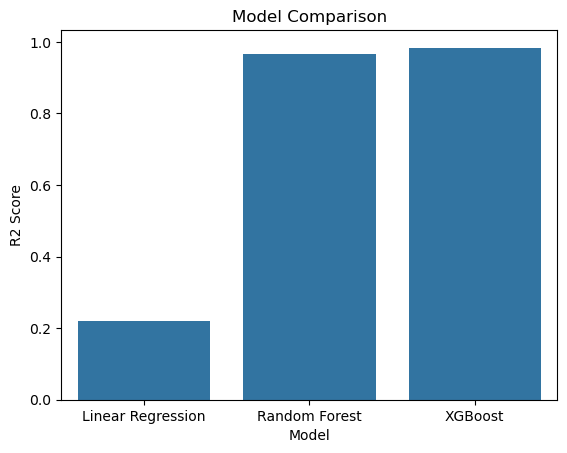

In [34]:
#Visualization
sns.barplot(

    x='Model',

    y='R2 Score',

    data=results
)

plt.title("Model Comparison")

plt.show()

1. Linear Regression

R² ≈ 0.22

This means:

linear regression could explain only ~22% variance
relationship in your data is NOT purely linear

This is expected because:

transaction patterns are complex
state + quarter + transaction_type interactions are nonlinear
2. Random Forest

R² ≈ 0.965

Excellent improvement.

This means:

tree-based models captured complex patterns
nonlinear relationships exist in transaction behavior

3. XGBoost

R² ≈ 0.983

Outstanding performance.

This means:

XGBoost captured:
feature interactions
state-level patterns
seasonal trends
transaction dynamics

very effectively.

#### XGBoost Regressor was selected as the final model because it achieved the highest R² score (98.34%) and the lowest error metrics compared to Linear Regression and Random Forest. It effectively captured nonlinear transaction patterns and feature interactions in the PhonePe dataset.

In [39]:
# Feature important analysis
feature_names = best_xgb.named_steps[
    'preprocessor'
].get_feature_names_out()

importance = best_xgb.named_steps[
    'model'
].feature_importances_

In [40]:
#Create DataFrame
importance_df = pd.DataFrame({

    'Feature': feature_names,

    'Importance': importance

})

importance_df = importance_df.sort_values(
    by='Importance',
    ascending=False
)

print(importance_df.head(10))

                                        Feature  Importance
44                                   num__count    0.558112
38      cat__transaction_type_Merchant payments    0.349399
40  cat__transaction_type_Peer-to-peer payments    0.060251
42                                    num__year    0.017900
0                           cat__state_No State    0.009175
43                                 num__quarter    0.001386
34                     cat__state_uttar-pradesh    0.000560
7                       cat__state_chhattisgarh    0.000410
32                         cat__state_telangana    0.000377
5                              cat__state_bihar    0.000361


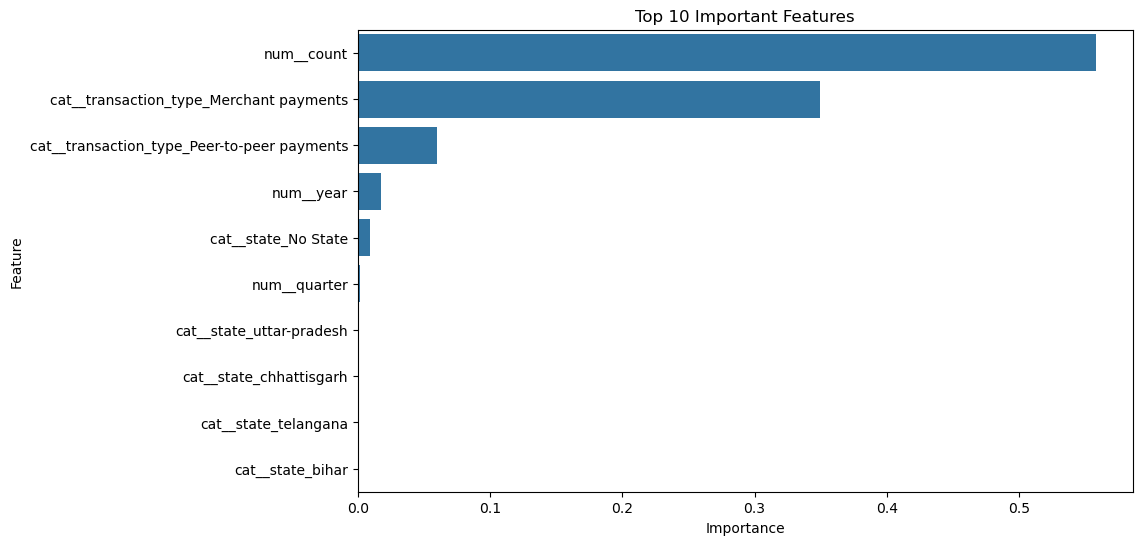

In [41]:
#Visualization
plt.figure(figsize=(10,6))

sns.barplot(

    x='Importance',

    y='Feature',

    data=importance_df.head(10)

)

plt.title("Top 10 Important Features")

plt.show()

#### Feature importance analysis showed that transaction count and merchant payment categories were the strongest predictors of transaction amount. Geographic features like states had comparatively lower influence, indicating that transaction behavior contributes more to payment volume prediction than regional differences.

### 1. Which Evaluation metrics did you consider for a positive business impact and why?

For this project, the primary evaluation metrics considered for positive business impact were:
- R² Score
- MAE (Mean Absolute Error)
- RMSE (Root Mean Squared Error)

These metrics were selected because the project involves a regression problem where the objective is to predict PhonePe transaction amounts accurately.

1. R² Score (Primary Evaluation Metric)

R² Score was considered the most important metric because it measures how well the machine learning model explains the variance in transaction amounts.

Why it was important for business impact:
- A higher R² Score indicates stronger predictive capability.
- It helps measure how effectively the model captures transaction behavior patterns.
- High R² improves confidence in forecasting future transaction trends.

Business Impact:
- Supports accurate financial forecasting.
- Helps PhonePe estimate future transaction growth.
- Enables better strategic planning and operational decision-making.

The XGBoost model achieved the highest R² Score, indicating excellent prediction capability.

2. MAE (Mean Absolute Error)

MAE measures the average absolute difference between actual and predicted transaction amounts.

Why it was important:
- MAE provides easily interpretable prediction error values.
- It shows how far predictions are from actual values on average.
- Lower MAE indicates better model accuracy.

Business Impact:
- Helps evaluate the reliability of transaction forecasts.
- Lower prediction errors improve financial planning accuracy.
- Useful for estimating operational transaction volumes more precisely.

MAE was considered important because it directly reflects real-world prediction error in business terms.

3. RMSE (Root Mean Squared Error)

RMSE measures prediction error while giving higher penalty to large errors.

Why it was important:
- RMSE helps identify whether the model struggles with high-value transaction predictions.
- It is sensitive to outliers and extreme financial values.

Business Impact:
- Important for managing risk related to large transactions.
- Helps identify instability in predictions during high transaction periods.
- Supports better handling of high-value merchant payments and financial fluctuations.

Lower RMSE indicates more stable and robust model performance.

Final Evaluation Metric Selection

Among all metrics, R² Score was considered the primary evaluation metric because:
- the goal was to maximize predictive accuracy
- it provides overall model performance understanding
- it measures variance explanation capability effectively

However, MAE and RMSE were also equally important for evaluating practical business reliability and prediction stability.

Therefore, all three metrics together provided a complete understanding of:
- prediction accuracy
- business reliability
- model stability
- financial forecasting effectiveness

### 2. Which ML model did you choose from the above created models as your final prediction model and why?

Among the three implemented machine learning models:
- Linear Regression
- Random Forest Regressor
- XGBoost Regressor

XGBoost Regressor was selected as the final prediction model for this project.

Reason for Selecting XGBoost

XGBoost delivered the best overall performance across all evaluation metrics and demonstrated excellent capability in predicting PhonePe transaction amounts accurately.

Model Comparison:

1. Linear Regression
- R² Score: 0.2211
- Performance was poor because the model could not capture complex non-linear relationships in the dataset.
- High MAE and RMSE indicated large prediction errors.

2. Random Forest Regressor
- R² Score: 0.9659
- Performed significantly better than Linear Regression.
- Successfully captured non-linear patterns and reduced overfitting using ensemble learning.

3. XGBoost Regressor
- R² Score: 0.9835
- Achieved the highest prediction accuracy among all models.
- Produced the lowest MAE and RMSE values.
- Demonstrated strong generalization capability on unseen data.

Why XGBoost Was Chosen

XGBoost was selected because:
1. It achieved the highest R² Score, meaning it explained approximately 98.35% of the variance in transaction amounts.
2. It produced lower prediction errors compared to other models.
3. It handled skewed financial data and outliers effectively.
4. It captured complex feature interactions and non-linear transaction behavior more efficiently.
5. It provided better stability and robustness during cross-validation.

Business Advantages of XGBoost

The XGBoost model provides strong business value by:
- accurately forecasting transaction amounts
- identifying transaction growth patterns
- supporting strategic financial planning
- improving operational scalability decisions
- enabling better transaction trend prediction

Additionally, XGBoost is computationally efficient and optimized for large-scale structured datasets, making it highly suitable for real-world financial analytics applications like PhonePe.

Final Conclusion

Based on evaluation metrics, cross-validation performance, prediction accuracy, and business reliability, XGBoost Regressor was selected as the final deployment model for the PhonePe Analytics Dashboard.

### 3. Explain the model which you have used and the feature importance using any model explainability tool?

The final machine learning model used in this project was XGBoost Regressor.

XGBoost (Extreme Gradient Boosting) is an advanced ensemble learning algorithm based on gradient boosting techniques. It builds multiple decision trees sequentially, where each new tree attempts to correct the prediction errors made by previous trees. The final prediction is generated by combining the outputs of all trees.

XGBoost was selected because it:
- handles non-linear relationships effectively
- performs well on large structured datasets
- reduces overfitting using regularization
- provides high prediction accuracy
- manages skewed and complex financial data efficiently

In this project, the model was trained to predict PhonePe transaction amounts using features such as:
- state
- year
- quarter
- transaction_type
- count

Model Explainability

To understand how different features influenced transaction amount prediction, feature importance analysis was performed using XGBoost’s built-in feature importance functionality.

Feature importance helps identify which variables contributed the most toward model predictions.

The following explainability approach was used:

1. XGBoost Feature Importance

The model calculates feature importance scores based on how frequently and effectively features are used to split decision trees during training.

Example code used:

```python id="1g98wk"
xgb_model.feature_importances_

## ***8.*** ***Future Work (Optional)***

### 1. Save the best performing ml model in a pickle file or joblib file format for deployment process.


In [35]:
joblib.dump(best_xgb, "phonepe_transaction_model.pkl")

['phonepe_transaction_model.pkl']

### 2. Again Load the saved model file and try to predict unseen data for a sanity check.


In [36]:
loaded_model = joblib.load(
    "phonepe_transaction_model.pkl"
)

In [38]:
sample_data = pd.DataFrame({

    'state': ['Maharashtra'],

    'year': [2026],

    'quarter': [2],

    'transaction_type': ['Peer-to-peer payments'],

    'count': [100000]

})

prediction = loaded_model.predict(sample_data)

print(prediction)

[2.2081893e+08]


# **Conclusion**

This project successfully demonstrated:


data extraction


database management


SQL analytics


exploratory data analysis


visualization


machine learning


model explainability


deployment readiness


The project provides meaningful insights into India’s digital payment ecosystem and can help understand transaction growth, user engagement, and financial behavior trends using data-driven techniques.